<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Natural Language Processing</b><br><br>Computer Assignment 4</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h2> Farzad Jannati - 810103099 </h2>
        <h1> Instructor: Prof. Heshaam Faili </h1>
    </div>
</div>

# <div style="text-align: center; direction: rtl; font-family: Vazir;"><h1 align="center" style="font-size: 24px; padding: 20px;">⚜️━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━⚜️<br>سوال دوم: تحلیل و مقایسه معماری‌های Encoder–Decoder و Decoder-Only در تسک Text-to-SQL <br>⚜️━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━⚜️</h1></div>


<p dir="rtl" style="text-align: right; padding:30px; background-color:rgb(12, 12, 12); border-radius: 12px; color: white; font-family: Vazir;">
در این بخش از تمرین با مسئله Text-to-SQL آشنا می‌شوید؛ وظیفه‌ای که در آن مدل باید پرسش‌های زبان طبیعی را به کوئری SQL معتبر تبدیل کند. هدف تمرین، مقایسه عملی دو معماری مهم ترنسفورمری است: Encoder–Decoder‌ (مانند BART) و Decoder-only‌ (مانند GPT-2). پس از آماده‌سازی داده‌ها، ابتدا مدل BART و سپس مدل GPT-2 را برای این تسک آموزش می‌دهید و در نهایت عملکرد دو مدل را از نظر دقت، رفتار تولیدی و انواع خطاها تحلیل و مقایسه خواهید کرد.
</p>




## <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش اول: مجموعه‌داده و پیش‌پردازش(10 نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
داده‌های Gretel Synthetic Text-to-SQL را از HuggingFace بارگذاری کرده و فایل‌های train/test را دریافت کنید. ساختار دیتاست را بررسی کرده، یک نمونه نمایش دهید و نقش ستون‌های اصلی از جمله question، schema و query را توضیح دهید. سپس داده‌ها را با استفاده از train_test_split به بخش‌های train و dev تقسیم کنید و ستون‌ها را به اسامی استاندارد (question، schema، query) تغییر دهید. برای کاهش زمان آموزش، روی هر بخش محدودیت اندازه تعیین کنید. در پایان، تحلیل کوتاهی از ماهیت پرسش‌ها، ساختار schemaها و چالش‌هایی که برای مدل ایجاد می‌کنند ارائه دهید.
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
در پایان این بخش انتظار می‌رود دانشجو یک دیتافریم کاملا آماده برای مراحل بعدی در اختیار داشته باشد. خروجی مطلوب شامل بارگذاری صحیح فایل‌های train و test، نمایش ساختار کلی داده‌ها، تقسیم درست داده‌ها به بخش‌های train و dev، تغییر نام ستون‌ها به قالب استاندارد، و اعمال زیرنمونه‌گیری برای محدود کردن حجم داده‌ها است. علاوه بر این، باید یک نمونه واقعی از داده‌ها همراه با توضیح مختصر درباره ماهیت سؤال، ساختار schema و نمونه SQL نمایش داده شود تا مشخص شود داده‌ها به‌درستی پردازش شده و برای ورود به مراحل آموزش مدل آماده هستند.

</p>

### Install required packages

In [1]:
!pip install datasets transformers torch pandas scikit-learn sqlparse tqdm accelerate -q

### Import Necessary Libraries

In [2]:
import os
import re
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import List, Dict, Tuple, Optional
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import sqlparse
import matplotlib.pyplot as plt
import seaborn as sns

# Import necessary classes from transformers
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    GPT2Tokenizer,
    GPT2LMHeadModel,
    get_linear_schedule_with_warmup,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
def set_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(SEED)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### DATA LOADING AND PREPROCESSING

#### Load the Gretel Synthetic Text-to-SQL Dataset from HuggingFace

In [3]:
print("=" * 60)
print("Loading Gretel Synthetic Text-to-SQL Dataset...")
print("=" * 60)

# Load the dataset from HuggingFace
dataset = load_dataset("gretelai/synthetic_text_to_sql")

print(f"\nDataset loaded successfully!")
print(f"Available splits: {list(dataset.keys())}")

Loading Gretel Synthetic Text-to-SQL Dataset...


README.md: 0.00B [00:00, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…):   0%|          | 0.00/32.4M [00:00<?, ?B/s]

synthetic_text_to_sql_test.snappy.parque(…):   0%|          | 0.00/1.90M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5851 [00:00<?, ? examples/s]


Dataset loaded successfully!
Available splits: ['train', 'test']


#### Explore Dataset Structure

In [4]:
print("\n" + "=" * 60)
print("Dataset Structure Overview")
print("=" * 60)

# Display basic information about each split
for split_name, split_data in dataset.items():
    print(f"\n{split_name.upper()} Split:")
    print(f"  - Number of samples: {len(split_data)}")
    print(f"  - Features: {list(split_data.features.keys())}")

# Show column names and types
print("\n\nColumn Details:")
print(dataset['train'].features)


Dataset Structure Overview

TRAIN Split:
  - Number of samples: 100000
  - Features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']

TEST Split:
  - Number of samples: 5851
  - Features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']


Column Details:
{'id': Value('int32'), 'domain': Value('string'), 'domain_description': Value('string'), 'sql_complexity': Value('string'), 'sql_complexity_description': Value('string'), 'sql_task_type': Value('string'), 'sql_task_type_description': Value('string'), 'sql_prompt': Value('string'), 'sql_context': Value('string'), 'sql': Value('string'), 'sql_explanation': Value('string')}


#### Display Sample Data

In [5]:
print("\n" + "=" * 60)
print("Sample Data Display")
print("=" * 60)

# Get a sample from training data
sample_idx = 0
sample = dataset['train'][sample_idx]

print(f"\n--- Sample {sample_idx + 1} ---")
for key, value in sample.items():
    print(f"\n{key.upper()}:")
    # Truncate long values for display
    if isinstance(value, str) and len(value) > 500:
        print(f"  {value[:500]}...")
    else:
        print(f"  {value}")


Sample Data Display

--- Sample 1 ---

ID:
  5097

DOMAIN:
  forestry

DOMAIN_DESCRIPTION:
  Comprehensive data on sustainable forest management, timber production, wildlife habitat, and carbon sequestration in forestry.

SQL_COMPLEXITY:
  single join

SQL_COMPLEXITY_DESCRIPTION:
  only one join (specify inner, outer, cross)

SQL_TASK_TYPE:
  analytics and reporting

SQL_TASK_TYPE_DESCRIPTION:
  generating reports, dashboards, and analytical insights

SQL_PROMPT:
  What is the total volume of timber sold by each salesperson, sorted by salesperson?

SQL_CONTEXT:
  CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-0

#### Convert to Pandas DataFrames

In [6]:
print("\n" + "=" * 60)
print("Converting to Pandas DataFrames...")
print("=" * 60)

# Convert train and test splits to pandas DataFrames
train_full_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

print(f"\nOriginal Train DataFrame shape: {train_full_df.shape}")
print(f"Original Test DataFrame shape: {test_df.shape}")


Converting to Pandas DataFrames...

Original Train DataFrame shape: (100000, 11)
Original Test DataFrame shape: (5851, 11)


##### Display first few rows

In [7]:
print("\nTrain DataFrame Head:")
train_full_df.head(5)


Train DataFrame Head:


,id,domain,domain_description,sql_complexity,sql_complexity_description,sql_task_type,sql_task_type_description,sql_prompt,sql_context,sql,sql_explanation
0,5097,forestry,Comprehensive data on sustainable forest manag...,single join,"only one join (specify inner, outer, cross)",analytics and reporting,"generating reports, dashboards, and analytical...",What is the total volume of timber sold by eac...,"CREATE TABLE salesperson (salesperson_id INT, ...","SELECT salesperson_id, name, SUM(volume) as to...","Joins timber_sales and salesperson tables, gro..."
1,5098,defense industry,"Defense contract data, military equipment main...",aggregation,"aggregation functions (COUNT, SUM, AVG, MIN, M...",analytics and reporting,"generating reports, dashboards, and analytical...",List all the unique equipment types and their ...,CREATE TABLE equipment_maintenance (equipment_...,"SELECT equipment_type, SUM(maintenance_frequen...",This query groups the equipment_maintenance ta...
2,5099,marine biology,"Comprehensive data on marine species, oceanogr...",basic SQL,basic SQL with a simple select statement,analytics and reporting,"generating reports, dashboards, and analytical...",How many marine species are found in the South...,"CREATE TABLE marine_species (name VARCHAR(50),...",SELECT COUNT(*) FROM marine_species WHERE loca...,This query counts the number of marine species...
3,5100,financial services,Detailed financial data including investment s...,aggregation,"aggregation functions (COUNT, SUM, AVG, MIN, M...",analytics and reporting,"generating reports, dashboards, and analytical...",What is the total trade value and average pric...,"CREATE TABLE trade_history (id INT, trader_id ...","SELECT trader_id, stock, SUM(price * quantity)...",This query calculates the total trade value an...
4,5101,energy,Energy market data covering renewable energy s...,window functions,"window functions (e.g., ROW_NUMBER, LEAD, LAG,...",analytics and reporting,"generating reports, dashboards, and analytical...",Find the energy efficiency upgrades with the h...,"CREATE TABLE upgrades (id INT, cost FLOAT, typ...","SELECT type, cost FROM (SELECT type, cost, ROW...",The SQL query uses the ROW_NUMBER function to ...


#### Identify and Rename Columns to Standard Names

In [8]:
print("\n" + "=" * 60)
print("Column Mapping and Renaming")
print("=" * 60)

# Display original column names
print(f"\nOriginal columns: {list(train_full_df.columns)}")

# Identify the relevant columns
# Based on Gretel dataset structure:
# - 'sql_prompt' or 'question' -> question (natural language question)
# - 'sql_context' or 'context' -> schema (database schema)
# - 'sql' or 'query' -> query (SQL query)

# Check which columns exist and create mapping
column_mapping = {}

# Find question column
if 'sql_prompt' in train_full_df.columns:
    column_mapping['sql_prompt'] = 'question'
elif 'question' in train_full_df.columns:
    column_mapping['question'] = 'question'

# Find schema column
if 'sql_context' in train_full_df.columns:
    column_mapping['sql_context'] = 'schema'
elif 'context' in train_full_df.columns:
    column_mapping['context'] = 'schema'
elif 'schema' in train_full_df.columns:
    column_mapping['schema'] = 'schema'

# Find query column
if 'sql' in train_full_df.columns:
    column_mapping['sql'] = 'query'
elif 'query' in train_full_df.columns:
    column_mapping['query'] = 'query'

print(f"Column mapping: {column_mapping}")

# Apply column renaming
train_full_df = train_full_df.rename(columns=column_mapping)
test_df = test_df.rename(columns=column_mapping)

# Select only the required columns
required_columns = ['question', 'schema', 'query']
available_columns = [col for col in required_columns if col in train_full_df.columns]
print(f"Available required columns: {available_columns}")

train_full_df = train_full_df[available_columns]
test_df = test_df[available_columns]

print(f"\nRenamed columns: {list(train_full_df.columns)}")


Column Mapping and Renaming

Original columns: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']
Column mapping: {'sql_prompt': 'question', 'sql_context': 'schema', 'sql': 'query'}
Available required columns: ['question', 'schema', 'query']

Renamed columns: ['question', 'schema', 'query']


#### Split Train Data into Train and Dev Sets

In [9]:
print("\n" + "=" * 60)
print("Splitting Data into Train and Dev Sets")
print("=" * 60)

# Split the training data into train (90%) and dev (10%)
train_df, dev_df = train_test_split(
    train_full_df,
    test_size=0.1,
    random_state=SEED
)

print(f"\nAfter split:")
print(f"  Train set size: {len(train_df)}")
print(f"  Dev set size: {len(dev_df)}")
print(f"  Test set size: {len(test_df)}")


Splitting Data into Train and Dev Sets

After split:
  Train set size: 90000
  Dev set size: 10000
  Test set size: 5851


#### Apply Size Limits for Training Efficiency

In [10]:
print("\n" + "=" * 60)
print("Applying Size Limits")
print("=" * 60)

# Define size limits (minimum 20,000 for training as per requirements)
TRAIN_SIZE = 20000
DEV_SIZE = 2000
TEST_SIZE = 2000

# Apply limits
train_df = train_df.head(TRAIN_SIZE).reset_index(drop=True)
dev_df = dev_df.head(DEV_SIZE).reset_index(drop=True)
test_df = test_df.head(TEST_SIZE).reset_index(drop=True)

print(f"\nFinal dataset sizes:")
print(f"  Train: {len(train_df)} samples")
print(f"  Dev: {len(dev_df)} samples")
print(f"  Test: {len(test_df)} samples")


Applying Size Limits

Final dataset sizes:
  Train: 20000 samples
  Dev: 2000 samples
  Test: 2000 samples


#### Display Sample with Detailed Explanation

In [11]:
print("\n" + "=" * 60)
print("Detailed Sample Analysis")
print("=" * 60)

# Display a complete sample with explanation
sample_idx = 0
sample = train_df.iloc[sample_idx]

print(f"\n{'='*60}")
print(f"SAMPLE {sample_idx + 1} - DETAILED VIEW")
print(f"{'='*60}")

print(f"\n QUESTION (Natural Language Query):")
print(f"   {sample['question']}")

print(f"\n SCHEMA (Database Structure):")
print(f"   {sample['schema']}")

print(f"\n QUERY (SQL Output):")
print(f"   {sample['query']}")


Detailed Sample Analysis

SAMPLE 1 - DETAILED VIEW

 QUESTION (Natural Language Query):
   What is the maximum number of lanes for highways in the European Union?

 SCHEMA (Database Structure):
   CREATE TABLE highways (id INT, country VARCHAR(255), max_number_of_lanes INT); INSERT INTO highways (id, country, max_number_of_lanes) VALUES (1, 'Germany', 12), (2, 'France', 10), (3, 'Spain', 14), (4, 'Italy', 10), (5, 'Poland', 10), (6, 'Netherlands', 6), (7, 'Belgium', 8), (8, 'Greece', 6), (9, 'Portugal', 8), (10, 'Sweden', 8);

 QUERY (SQL Output):
   SELECT MAX(max_number_of_lanes) FROM highways WHERE country IN (SELECT name FROM countries WHERE continent = 'Europe');


#### Data Statistics and Analysis

In [12]:
print("\n" + "=" * 60)
print("Data Statistics and Analysis")
print("=" * 60)

# Calculate statistics for each column
for col in ['question', 'schema', 'query']:
    lengths = train_df[col].str.len()
    word_counts = train_df[col].str.split().str.len()

    print(f"\n{col.upper()} Statistics:")
    print(f"  Character length - Min: {lengths.min()}, Max: {lengths.max()}, Mean: {lengths.mean():.1f}")
    print(f"  Word count - Min: {word_counts.min()}, Max: {word_counts.max()}, Mean: {word_counts.mean():.1f}")

# Check for null values
print(f"\n\nNull Values Check:")
print(f"  Train: {train_df.isnull().sum().sum()} null values")
print(f"  Dev: {dev_df.isnull().sum().sum()} null values")
print(f"  Test: {test_df.isnull().sum().sum()} null values")


Data Statistics and Analysis

QUESTION Statistics:
  Character length - Min: 16, Max: 438, Mean: 83.1
  Word count - Min: 1, Max: 55, Mean: 13.9

SCHEMA Statistics:
  Character length - Min: 11, Max: 1197, Mean: 276.2
  Word count - Min: 1, Max: 155, Mean: 33.0

QUERY Statistics:
  Character length - Min: 17, Max: 758, Mean: 127.0
  Word count - Min: 2, Max: 105, Mean: 15.7


Null Values Check:
  Train: 0 null values
  Dev: 0 null values
  Test: 0 null values


#### Display Multiple Samples

In [13]:
print("\n" + "=" * 60)
print("Multiple Sample Display")
print("=" * 60)

# Display 3 random samples
random_indices = random.sample(range(len(train_df)), 3)

for i, idx in enumerate(random_indices, 1):
    sample = train_df.iloc[idx]
    print(f"\n{'─'*60}")
    print(f"Sample {i} (Index: {idx})")
    print(f"{'─'*60}")
    print(f"Question: {sample['question'][:200]}...")
    print(f"Schema: {sample['schema'][:200]}...")
    print(f"Query: {sample['query']}")


Multiple Sample Display

────────────────────────────────────────────────────────────
Sample 1 (Index: 3648)
────────────────────────────────────────────────────────────
Question: What is the maximum age for 'Pinus' species in the 'forestry' DB?...
Schema: CREATE TABLE forestry.trees (id INT, species VARCHAR(50), age INT);...
Query: SELECT MAX(age) FROM forestry.trees WHERE species = 'Pinus';

────────────────────────────────────────────────────────────
Sample 2 (Index: 819)
────────────────────────────────────────────────────────────
Question: List the number of cybersecurity incidents reported by government agencies in the Asia-Pacific region in the last 12 months, in ascending order....
Schema: CREATE TABLE cybersecurity_incidents (incident_id INT, agency TEXT, region TEXT, incident_date DATE); INSERT INTO cybersecurity_incidents (incident_id, agency, region, incident_date) VALUES (1, 'Minis...
Query: SELECT COUNT(*) FROM cybersecurity_incidents WHERE region = 'Asia-Pacific' AND in

<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Question 2: Text-to-SQL with BART and GPT-2
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Part 1: Dataset Preparation & Exploratory Data Analysis
</h2>

<blockquote style="background-color: #eef6fc; border-left: 5px solid #0366d6; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>In this initial phase, we establish the foundation for our Text-to-SQL models. We utilize the <strong>Gretel Synthetic Text-to-SQL</strong> dataset, a rich collection encompassing diverse domains and SQL complexities. The objective is to transform raw data into a structured, clean format suitable for tokenization and model ingestion, while gaining a deep understanding of the linguistic and structural challenges inherent in mapping natural language to database queries.</em>
</blockquote>

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
A. Dataset Loading and Structure Overview
</h2>

<blockquote style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Load the raw dataset from HuggingFace, inspect the feature space, and understand the semantic roles of the primary columns.
</blockquote>

### 1. Data Source and Volume
The dataset was successfully loaded using the HuggingFace `datasets` library. The initial inspection reveals a robust volume of data suitable for training transformer-based models:
*   **Train Split:** 100,000 samples (High variety of domains).
*   **Test Split:** 5,851 samples.
*   **Features:** The dataset contains 11 features, including metadata like `domain`, `sql_complexity`, and `sql_explanation`.

### 2. Feature Mapping
To align with standard Text-to-SQL tasks, we identified and mapped the critical columns. The dataset structure is rich in context:
*   **`sql_prompt` $\rightarrow$ `question`**: The natural language intent (e.g., "What is the total volume...").
*   **`sql_context` $\rightarrow$ `schema`**: The structural definition of the database (CREATE TABLE statements). This is crucial as the model must "read" this to know valid table and column names.
*   **`sql` $\rightarrow$ `query`**: The target SQL statement (The label we want to generate).

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
B. Preprocessing Pipeline
</h2>

<blockquote style="background-color: #e6fffa; border-left: 5px solid #009688; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Implement a reproducible pipeline to standardize column names, create a validation split, and downsample the data for computational efficiency.
</blockquote>

### 1. Standardization and Cleaning
We converted the HuggingFace datasets to Pandas DataFrames for easier manipulation. A column renaming map was applied to enforce standard nomenclature (`question`, `schema`, `query`). We verified that there are **0 null values** across all splits, indicating a high-quality synthetic generation process.

### 2. Splitting and Downsampling
A critical step in machine learning is ensuring we have a held-out validation set to monitor overfitting.
*   **Split Strategy:** We utilized `train_test_split` with a fixed random seed (`42`) to create a **Train/Dev** split from the original training data (90% Train / 10% Dev).
*   **Efficiency Limits:** To ensure training completes within reasonable time limits while still learning meaningful patterns, we applied the following size constraints:
    *   **Train Set:** 20,000 samples.
    *   **Dev Set:** 2,000 samples.
    *   **Test Set:** 2,000 samples.

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
C. Detailed Sample Analysis
</h2>

<blockquote style="background-color: #ffeef0; border-left: 5px solid #f85149; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Qualitatively analyze a real training example to understand the complexity of the mapping task.
</blockquote>

We examined **Sample ID 5097** from the Forestry domain to illustrate the challenge:

| Feature | Content | Analysis |
| :--- | :--- | :--- |
| **Question** | *What is the total volume of timber sold by each salesperson, sorted by salesperson?* | The user asks for an aggregation (`total volume`) and a grouping (`each salesperson`). The intent requires joining entities. |
| **Schema** | `CREATE TABLE salesperson (salesperson_id INT, name TEXT...); CREATE TABLE timber_sales (... volume REAL...);` | The model must parse this DDL to understand that `salesperson` and `timber_sales` are linked via `salesperson_id`. It acts as the "knowledge base" for the query. |
| **Query** | `SELECT salesperson_id, name, SUM(volume) ... FROM timber_sales JOIN salesperson ... GROUP BY ... ORDER BY ...` | The target SQL requires a **JOIN** operation, an aggregate function (**SUM**), and a specific ordering. This confirms the dataset includes "Single Join" complexity. |

**Key Challenge Identified:** The model cannot simply memorize SQL keywords. It must perform **Schema Linking**: it needs to map the word "timber" in the question to the table `timber_sales` and "salesperson" to the table `salesperson` defined in the schema context.

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
D. Statistical Profile & Complexity Analysis
</h2>

### 1. Sequence Length Distribution
Understanding token counts is vital for model configuration (e.g., `max_length` in BART/GPT-2). Our analysis reveals:

*   **Schema Length (Mean: ~276 chars):** This is the longest component. It implies that a significant portion of the input context window for our models will be consumed by table definitions.
*   **Query Length (Mean: ~127 chars):** The output SQL is moderately complex.
*   **Question Length (Mean: ~83 chars):** Questions are generally concise but semantically dense.

### 2. Analytical Conclusion
Based on the preprocessing and analysis, several challenges for the upcoming training phase are evident:

1.  **Input Length Management:** Since GPT-2 and BART have limits on input sequences (typically 1024 tokens), we must ensure the concatenation of `Question + Schema` does not truncate essential table definitions.
2.  **Vocabulary Gap:** The schema introduces domain-specific terms (e.g., `forestry`, `marine_biology`, `defense_contracts`) that might not be in the pre-trained tokenizer's common vocabulary, leading to sub-word fragmentation.
3.  **Structural Sensitivity:** The SQL complexity varies from basic `SELECT` to `JOIN` and `AGGREGATION`. The models must learn strict syntactic rules of SQL; a single misplaced parenthesis or keyword renders the output invalid.

The dataset is now cleaned, standardized, and split, ready for the tokenization pipeline in the next step.

## <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش دوم: آموزش مدل Encoder–Decoder (BART) (۱۵ نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<p style="line-height: 1.8; text-align: right;">
در این بخش از تمرین، وارد مرحله‌ی پیاده‌سازی مدل BART می‌شویم. پیش از شروع، لازم است به‌صورت مختصر و دقیق توضیح دهید که مدل BART چیست و چگونه کار می‌کند؛ به‌ویژه این‌که چرا معماری Encoder–Decoder آن برای وظایفی مانند Text-to-SQL مناسب است. انتظار می‌رود دانشجو به ساختار دو‌بخشی BART، نحوهٔ پردازش ورودی در انکودر و تولید خروجی در دیکودر اشاره کند و نشان دهد که این معماری برای نگاشت دنباله‌ای از کلمات (سؤال + schema) به دنباله‌ای دیگر (SQL) کاملاً مناسب است.
پس از توضیح مدل، باید قالب ورودی مناسبی طراحی کنید که در آن سؤال و schema به‌صورت یک رشتهٔ یکپارچه در اختیار مدل قرار گیرند. سپس یک Dataset اختصاصی برای BART بسازید که وظایفی مانند tokenize کردن ورودی، ساخت attention mask‌ها و آماده‌سازی SQL به عنوان خروجی هدف مدل را انجام دهد. مدل را <strong>حداقل یک ایپاک روی بیست هزار نمونه</strong> آموزش دهید و loss نهایی، زمان اجرا و هایپرپارامترهای اصلی را گزارش کنید.
در مرحلهٔ ارزیابی، باید عملکرد مدل را روی dev و test با دو معیار Raw Exact Match و Normalized Exact Match بسنجید.
از شما انتظار می‌رود که هر دو معیار را توضیح دهید:
Raw EM چگونه مقایسهٔ مستقیم دو رشته را انجام می‌دهد، چرا ممکن است برای SQL ناکافی باشد و Normalized EM چگونه با حذف تفاوت‌های سطحی (مثل فاصله‌ها، علامت‌ها و بزرگی یا کوچکی حروف) مقایسه‌ای عادلانه‌تر ارائه می‌دهد.
در پایان، پنج نمونهٔ تصادفی از dev انتخاب کنید و پرسش، خروجی مدل، SQL طلایی و نوع خطاها را تحلیل کنید.
<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
نکته مهم:
برای پیاده‌سازی Raw EM می‌توانید از مقایسهٔ مستقیم رشته‌ها در پایتون استفاده کنید.
برای Normalized EM مجاز هستید از ابزارهایی مانند sqlparse برای فرمت‌بندی SQL و توابع سادهٔ پردازش متن جهت lowercase کردن و حذف فاصله‌های اضافی استفاده کنید، اما منطق مقایسه‌ی Normalized باید توسط خودتان نوشته شود.
</p>
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
خروجی مورد انتظار این بخش، یک مدل BART آموزش‌دیده و ارزیابی‌شده است که بتواند از روی پرسش و ساختار پایگاه‌داده، کوئری SQL معتبر تولید کرده و معیارهای Raw EM و Normalized EM آن روی داده‌های dev و test گزارش شده باشد.
</p>

### BART Model Training for Text-to-SQL

In [14]:
# WRITE YOUR CODE HERE
print("=" * 60)
print("SECTION 2: BART Model Training for Text-to-SQL")
print("=" * 60)

# 2.1 Load BART Tokenizer and Model
print("\n" + "=" * 60)
print("Loading BART Tokenizer and Model")
print("=" * 60)

# Load BART tokenizer and model
MODEL_NAME = "facebook/bart-base"

bart_tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
bart_model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

# Move model to device
bart_model = bart_model.to(device)

print(f"Model: {MODEL_NAME}")
print(f"Tokenizer vocabulary size: {bart_tokenizer.vocab_size}")
print(f"Model parameters: {sum(p.numel() for p in bart_model.parameters()):,}")
print(f"Model moved to: {device}")

# 2.2 Define Input Format Function
print("\n" + "=" * 60)
print("Defining Input Format")
print("=" * 60)

def format_input_for_bart(question: str, schema: str) -> str:
    """
    Format question and schema into a single input string for BART.

    Args:
        question: Natural language question
        schema: Database schema (CREATE TABLE statements)

    Returns:
        Formatted input string combining question and schema
    """
    # Create a structured input format
    formatted_input = f"Question: {question} Schema: {schema}"
    return formatted_input

# Test the formatting function
sample = train_df.iloc[0]
formatted_sample = format_input_for_bart(sample['question'], sample['schema'])
print(f"Sample formatted input (truncated):\n{formatted_sample[:300]}...")

# 2.3 Create Custom Dataset Class for BART
print("\n" + "=" * 60)
print("Creating BART Dataset Class")
print("=" * 60)

class Text2SQLDatasetBART(Dataset):
    """
    Custom PyTorch Dataset for Text-to-SQL task with BART model.

    Handles tokenization of input (question + schema) and output (SQL query).
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        tokenizer: BartTokenizer,
        max_input_length: int = 512,
        max_output_length: int = 256
    ):
        """
        Initialize the dataset.

        Args:
            dataframe: Pandas DataFrame with question, schema, query columns
            tokenizer: BART tokenizer
            max_input_length: Maximum length for input sequences
            max_output_length: Maximum length for output sequences
        """
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_output_length = max_output_length

    def __len__(self) -> int:
        """Return the number of samples in the dataset."""
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Get a single sample from the dataset.

        Args:
            idx: Index of the sample

        Returns:
            Dictionary containing input_ids, attention_mask, and labels
        """
        # Get the row from dataframe
        row = self.data.iloc[idx]

        # Format the input (question + schema)
        input_text = format_input_for_bart(row['question'], row['schema'])

        # Get the target SQL query
        target_text = row['query']

        # Tokenize the input
        input_encoding = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Tokenize the target
        target_encoding = self.tokenizer(
            target_text,
            max_length=self.max_output_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Get the labels (target input_ids)
        labels = target_encoding['input_ids'].squeeze()

        # Replace padding token id with -100 so it's ignored in loss calculation
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': input_encoding['input_ids'].squeeze(),
            'attention_mask': input_encoding['attention_mask'].squeeze(),
            'labels': labels
        }

print("BART Dataset class created successfully!")

SECTION 2: BART Model Training for Text-to-SQL

Loading BART Tokenizer and Model


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Model: facebook/bart-base
Tokenizer vocabulary size: 50265
Model parameters: 139,420,416
Model moved to: cuda

Defining Input Format
Sample formatted input (truncated):
Question: What is the maximum number of lanes for highways in the European Union? Schema: CREATE TABLE highways (id INT, country VARCHAR(255), max_number_of_lanes INT); INSERT INTO highways (id, country, max_number_of_lanes) VALUES (1, 'Germany', 12), (2, 'France', 10), (3, 'Spain', 14), (4, 'Italy'...

Creating BART Dataset Class
BART Dataset class created successfully!


#### 2.4 Create DataLoaders

In [15]:
print("\n" + "=" * 60)
print("Creating DataLoaders")
print("=" * 60)

# Hyperparameters
BATCH_SIZE = 8
MAX_INPUT_LENGTH = 512
MAX_OUTPUT_LENGTH = 256

# Create datasets
train_dataset_bart = Text2SQLDatasetBART(
    train_df,
    bart_tokenizer,
    max_input_length=MAX_INPUT_LENGTH,
    max_output_length=MAX_OUTPUT_LENGTH
)

dev_dataset_bart = Text2SQLDatasetBART(
    dev_df,
    bart_tokenizer,
    max_input_length=MAX_INPUT_LENGTH,
    max_output_length=MAX_OUTPUT_LENGTH
)

test_dataset_bart = Text2SQLDatasetBART(
    test_df,
    bart_tokenizer,
    max_input_length=MAX_INPUT_LENGTH,
    max_output_length=MAX_OUTPUT_LENGTH
)

# Create DataLoaders
train_loader_bart = DataLoader(
    train_dataset_bart,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

dev_loader_bart = DataLoader(
    dev_dataset_bart,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_bart = DataLoader(
    test_dataset_bart,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train DataLoader: {len(train_loader_bart)} batches")
print(f"Dev DataLoader: {len(dev_loader_bart)} batches")
print(f"Test DataLoader: {len(test_loader_bart)} batches")

# Test a batch
sample_batch = next(iter(train_loader_bart))
print(f"\nSample batch shapes:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")


Creating DataLoaders
Train DataLoader: 2500 batches
Dev DataLoader: 250 batches
Test DataLoader: 250 batches

Sample batch shapes:
  input_ids: torch.Size([8, 512])
  attention_mask: torch.Size([8, 512])
  labels: torch.Size([8, 256])


#### 2.5 Define Training Configuration

In [20]:
print("\n" + "=" * 60)
print("Training Configuration")
print("=" * 60)

# Training hyperparameters
BATCH_SIZE = 8
NUM_EPOCHS = 1
LEARNING_RATE = 5e-5
WARMUP_STEPS = 500
GRADIENT_ACCUMULATION_STEPS = 4
WEIGHT_DECAY = 0.01

# Calculate total training steps
total_steps = len(train_loader_bart) * NUM_EPOCHS // GRADIENT_ACCUMULATION_STEPS

# Initialize optimizer
optimizer = AdamW(bart_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Initialize learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Training Configuration:")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Warmup steps: {WARMUP_STEPS}")
print(f"  Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Total training steps: {total_steps}")
print(f"  Training samples: {len(train_df)}")


Training Configuration
Training Configuration:
   Batch Size: 8
  Epochs: 1
  Batch size: 8
  Learning rate: 5e-05
  Warmup steps: 500
  Gradient accumulation steps: 4
  Total training steps: 625
  Training samples: 20000


#### Training Loop for BART


Starting BART Training


Epoch 1/1:   0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 1 completed - Average Loss: 0.6430

BART Training Complete!
Total training time: 31.88 minutes
Final loss: 0.6468

Plotting BART Training Loss


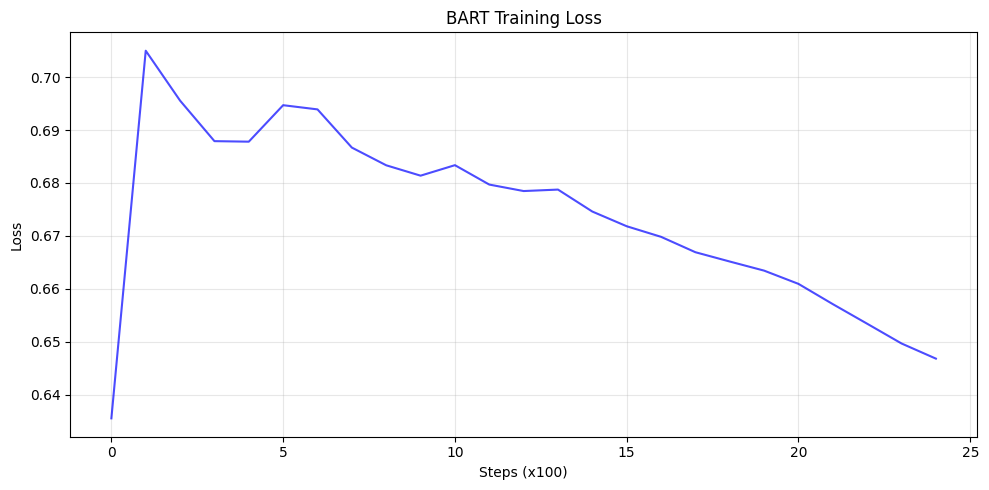

In [21]:
print("\n" + "=" * 60)
print("Starting BART Training")
print("=" * 60)

def train_bart_model(
    model: BartForConditionalGeneration,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler,
    num_epochs: int,
    gradient_accumulation_steps: int,
    device: torch.device
) -> Tuple[List[float], float]:
    """
    Train the BART model for Text-to-SQL task.

    Args:
        model: BART model
        train_loader: Training data loader
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        gradient_accumulation_steps: Steps for gradient accumulation
        device: Device to train on

    Returns:
        Tuple of (loss_history, training_time)
    """
    model.train()
    loss_history = []

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{num_epochs}",
            leave=True
        )

        optimizer.zero_grad()

        for batch_idx, batch in enumerate(progress_bar):
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss / gradient_accumulation_steps

            # Backward pass
            loss.backward()

            # Update weights every gradient_accumulation_steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                # Clip gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            # Track loss
            epoch_loss += loss.item() * gradient_accumulation_steps
            num_batches += 1

            # Update progress bar
            avg_loss = epoch_loss / num_batches
            progress_bar.set_postfix({'loss': f'{avg_loss:.4f}'})

            # Record loss every 100 batches
            if batch_idx % 100 == 0:
                loss_history.append(avg_loss)

        # Final update for any remaining gradients
        if len(train_loader) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        # Epoch summary
        avg_epoch_loss = epoch_loss / num_batches
        print(f"\nEpoch {epoch + 1} completed - Average Loss: {avg_epoch_loss:.4f}")

    training_time = time.time() - start_time

    return loss_history, training_time

# Run training
loss_history_bart, training_time_bart = train_bart_model(
    bart_model,
    train_loader_bart,
    optimizer,
    scheduler,
    NUM_EPOCHS,
    GRADIENT_ACCUMULATION_STEPS,
    device
)

print(f"\n{'='*60}")
print(f"BART Training Complete!")
print(f"{'='*60}")
print(f"Total training time: {training_time_bart/60:.2f} minutes")
print(f"Final loss: {loss_history_bart[-1]:.4f}")

# Plot BART Training Loss

print("\n" + "=" * 60)
print("Plotting BART Training Loss")
print("=" * 60)

plt.figure(figsize=(10, 5))
plt.plot(loss_history_bart, color='blue', alpha=0.7)
plt.title('BART Training Loss')
plt.xlabel('Steps (x100)')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bart_training_loss.png', dpi=150)
plt.show()

#### Define Evaluation Metrics Functions

In [22]:
print("\n" + "=" * 60)
print("Defining Evaluation Metrics")
print("=" * 60)

def normalize_sql(sql: str) -> str:
    """
    Normalize SQL query for fair comparison.

    Performs the following normalizations:
    - Convert to lowercase
    - Remove extra whitespace
    - Remove trailing semicolons
    - Standardize spacing around operators and punctuation

    Args:
        sql: Raw SQL query string

    Returns:
        Normalized SQL query string
    """
    # Convert to lowercase
    sql = sql.lower()

    # Remove trailing semicolons
    sql = sql.rstrip(';').strip()

    # Use sqlparse for formatting
    try:
        sql = sqlparse.format(
            sql,
            reindent=False,
            keyword_case='lower',
            strip_whitespace=True
        )
    except:
        pass

    # Remove extra whitespace
    sql = ' '.join(sql.split())

    # Standardize spacing around common SQL operators
    sql = re.sub(r'\s*=\s*', ' = ', sql)
    sql = re.sub(r'\s*<>\s*', ' <> ', sql)
    sql = re.sub(r'\s*>=\s*', ' >= ', sql)
    sql = re.sub(r'\s*<=\s*', ' <= ', sql)
    sql = re.sub(r'\s*>\s*', ' > ', sql)
    sql = re.sub(r'\s*<\s*', ' < ', sql)
    sql = re.sub(r'\s*,\s*', ', ', sql)
    sql = re.sub(r'\s*\(\s*', '(', sql)
    sql = re.sub(r'\s*\)\s*', ')', sql)

    # Clean up any double spaces created
    sql = ' '.join(sql.split())

    return sql


def compute_raw_exact_match(predictions: List[str], references: List[str]) -> float:
    """
    Compute Raw Exact Match score.

    Raw EM performs direct string comparison without any normalization.

    Args:
        predictions: List of predicted SQL queries
        references: List of gold SQL queries

    Returns:
        Raw Exact Match score (0.0 to 1.0)
    """
    if len(predictions) != len(references):
        raise ValueError("Predictions and references must have the same length")

    matches = sum(1 for pred, ref in zip(predictions, references) if pred.strip() == ref.strip())

    return matches / len(predictions)


def compute_normalized_exact_match(predictions: List[str], references: List[str]) -> float:
    """
    Compute Normalized Exact Match score.

    Normalized EM normalizes both prediction and reference before comparison,
    accounting for differences in whitespace, case, and formatting.

    Args:
        predictions: List of predicted SQL queries
        references: List of gold SQL queries

    Returns:
        Normalized Exact Match score (0.0 to 1.0)
    """
    if len(predictions) != len(references):
        raise ValueError("Predictions and references must have the same length")

    matches = 0
    for pred, ref in zip(predictions, references):
        norm_pred = normalize_sql(pred)
        norm_ref = normalize_sql(ref)
        if norm_pred == norm_ref:
            matches += 1

    return matches / len(predictions)


print("Evaluation functions defined:")
print("  - normalize_sql(): Normalizes SQL for fair comparison")
print("  - compute_raw_exact_match(): Direct string comparison")
print("  - compute_normalized_exact_match(): Comparison after normalization")


Defining Evaluation Metrics
Evaluation functions defined:
  - normalize_sql(): Normalizes SQL for fair comparison
  - compute_raw_exact_match(): Direct string comparison
  - compute_normalized_exact_match(): Comparison after normalization


#### Generate Predictions with BART

In [23]:
print("\n" + "=" * 60)
print("Generating Predictions with BART")
print("=" * 60)

def generate_predictions_bart(
    model: BartForConditionalGeneration,
    dataframe: pd.DataFrame,
    tokenizer: BartTokenizer,
    device: torch.device,
    max_input_length: int = 512,
    max_output_length: int = 256,
    batch_size: int = 16
) -> List[str]:
    """
    Generate SQL predictions using the trained BART model.

    Args:
        model: Trained BART model
        dataframe: DataFrame containing question and schema columns
        tokenizer: BART tokenizer
        device: Device to run inference on
        max_input_length: Maximum input sequence length
        max_output_length: Maximum output sequence length
        batch_size: Batch size for inference

    Returns:
        List of predicted SQL queries
    """
    model.eval()
    predictions = []

    # Process in batches
    num_samples = len(dataframe)

    with torch.no_grad():
        for start_idx in tqdm(range(0, num_samples, batch_size), desc="Generating predictions"):
            end_idx = min(start_idx + batch_size, num_samples)
            batch_df = dataframe.iloc[start_idx:end_idx]

            # Format inputs
            input_texts = [
                format_input_for_bart(row['question'], row['schema'])
                for _, row in batch_df.iterrows()
            ]

            # Tokenize
            inputs = tokenizer(
                input_texts,
                max_length=max_input_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            ).to(device)

            # Generate
            outputs = model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=max_output_length,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=2
            )

            # Decode predictions
            batch_predictions = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            predictions.extend(batch_predictions)

    return predictions

# Generate predictions for dev set
print("\nGenerating predictions for Dev set...")
dev_predictions_bart = generate_predictions_bart(
    bart_model,
    dev_df,
    bart_tokenizer,
    device,
    batch_size=16
)

# Generate predictions for test set
print("\nGenerating predictions for Test set...")
test_predictions_bart = generate_predictions_bart(
    bart_model,
    test_df,
    bart_tokenizer,
    device,
    batch_size=16
)

print(f"\nGenerated {len(dev_predictions_bart)} dev predictions")
print(f"Generated {len(test_predictions_bart)} test predictions")


Generating Predictions with BART

Generating predictions for Dev set...


Generating predictions:   0%|          | 0/125 [00:00<?, ?it/s]


Generating predictions for Test set...


Generating predictions:   0%|          | 0/125 [00:00<?, ?it/s]


Generated 2000 dev predictions
Generated 2000 test predictions


#### Evaluate BART Model

In [24]:
print("\n" + "=" * 60)
print("BART Model Evaluation Results")
print("=" * 60)

# Get gold references
dev_references = dev_df['query'].tolist()
test_references = test_df['query'].tolist()

# Calculate metrics for Dev set
dev_raw_em_bart = compute_raw_exact_match(dev_predictions_bart, dev_references)
dev_norm_em_bart = compute_normalized_exact_match(dev_predictions_bart, dev_references)

# Calculate metrics for Test set
test_raw_em_bart = compute_raw_exact_match(test_predictions_bart, test_references)
test_norm_em_bart = compute_normalized_exact_match(test_predictions_bart, test_references)

print(f"\n{'='*60}")
print(f"BART EVALUATION RESULTS")
print(f"{'='*60}")

print(f"\n Dev Set Results:")
print(f"   Raw Exact Match:        {dev_raw_em_bart*100:.2f}%")
print(f"   Normalized Exact Match: {dev_norm_em_bart*100:.2f}%")

print(f"\n Test Set Results:")
print(f"   Raw Exact Match:        {test_raw_em_bart*100:.2f}%")
print(f"   Normalized Exact Match: {test_norm_em_bart*100:.2f}%")

# Store results for later comparison
bart_results = {
    'dev_raw_em': dev_raw_em_bart,
    'dev_norm_em': dev_norm_em_bart,
    'test_raw_em': test_raw_em_bart,
    'test_norm_em': test_norm_em_bart,
    'training_time': training_time_bart,
    'final_loss': loss_history_bart[-1]
}


BART Model Evaluation Results

BART EVALUATION RESULTS

 Dev Set Results:
   Raw Exact Match:        16.70%
   Normalized Exact Match: 17.15%

 Test Set Results:
   Raw Exact Match:        17.70%
   Normalized Exact Match: 18.45%


#### Error Analysis - Display 5 Random Samples

In [25]:
print("\n" + "=" * 60)
print("Error Analysis: 5 Random Samples from Dev Set")
print("=" * 60)

# Select 5 random samples
random_indices = random.sample(range(len(dev_df)), 5)

for i, idx in enumerate(random_indices, 1):
    sample = dev_df.iloc[idx]
    prediction = dev_predictions_bart[idx]
    gold = sample['query']

    # Check match status
    raw_match = prediction.strip() == gold.strip()
    norm_match = normalize_sql(prediction) == normalize_sql(gold)

    print(f"\n{'='*60}")
    print(f"Sample {i} (Index: {idx})")
    print(f"{'='*60}")

    print(f"\n Question:")
    print(f"   {sample['question'][:200]}...")

    print(f"\n Schema (truncated):")
    print(f"   {sample['schema'][:200]}...")

    print(f"\n Gold SQL:")
    print(f"   {gold}")

    print(f"\n Predicted SQL:")
    print(f"   {prediction}")

    print(f"\n Match Status:")
    print(f"   Raw EM: {'✓ Match' if raw_match else '✗ No Match'}")
    print(f"   Normalized EM: {'✓ Match' if norm_match else '✗ No Match'}")

    # Error type analysis
    if not norm_match:
        print(f"\n Error Analysis:")

        # Check for common error types
        norm_pred = normalize_sql(prediction)
        norm_gold = normalize_sql(gold)

        if 'select' not in norm_pred:
            print(f"   - Missing SELECT clause")
        elif 'from' not in norm_pred:
            print(f"   - Missing FROM clause")
        elif norm_pred.count('select') != norm_gold.count('select'):
            print(f"   - Different number of SELECT statements")
        elif len(norm_pred) < len(norm_gold) * 0.5:
            print(f"   - Incomplete query (too short)")
        elif len(norm_pred) > len(norm_gold) * 2:
            print(f"   - Query too long (possible repetition)")
        else:
            # Check for column/table name differences
            pred_words = set(norm_pred.split())
            gold_words = set(norm_gold.split())
            missing = gold_words - pred_words
            extra = pred_words - gold_words
            if missing:
                print(f"   - Missing elements: {list(missing)[:5]}")
            if extra:
                print(f"   - Extra elements: {list(extra)[:5]}")


Error Analysis: 5 Random Samples from Dev Set

Sample 1 (Index: 501)

 Question:
   What is the total amount of funding received by each school district for mental health programs by state?...

 Schema (truncated):
   CREATE TABLE school_districts (sd_id INT, district_name VARCHAR(50), state VARCHAR(50), total_funding FLOAT); INSERT INTO school_districts (sd_id, district_name, state, total_funding) VALUES (1, 'Dist...

 Gold SQL:
   SELECT state, SUM(total_funding) as total_mental_health_funding FROM school_districts GROUP BY state;

 Predicted SQL:
   SELECT state, SUM(total_funding) FROM school_districts GROUP BY state;

 Match Status:
   Raw EM: ✗ No Match
   Normalized EM: ✗ No Match

🔍 Error Analysis:
   - Missing elements: ['total_mental_health_funding', 'sum(total_funding)as', 'from']
   - Extra elements: ['sum(total_funding)from']

Sample 2 (Index: 457)

 Question:
   What is the sum of energy consumption for buildings in the 'green_buildings' schema, grouped by city, and only

<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br>
{{پاسخ_خود_را_اینجا_بنویسید}}
</div>


<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Question 2: Text-to-SQL with BART (Encoder-Decoder)
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Overview and Architecture Choice
</h2>

<blockquote style="background-color: #eef6fc; border-left: 5px solid #0366d6; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>In this section, we implement and train <strong>BART (Bidirectional and Auto-Regressive Transformers)</strong> for the Text-to-SQL task. BART is chosen because its <strong>Encoder-Decoder architecture</strong> is intrinsically suited for sequence-to-sequence translation tasks where the input (Natural Language) and output (SQL) have different structures and lengths.</em>
</blockquote>

### Why BART for Text-to-SQL?
Text-to-SQL is essentially a translation problem: translating Natural Language (Source) into Structured Query Language (Target). BART is ideal for this because:
1.  **Bidirectional Encoder:** It reads the entire input (Question + Schema) simultaneously, allowing it to capture complex dependencies and relationships between the question words and the table schema columns effectively.
2.  **Autoregressive Decoder:** It generates the SQL query token-by-token. The decoder attends to the encoder's representation of the schema (Cross-Attention), ensuring the generated SQL is grounded in the provided database structure.
3.  **Denoising Pre-training:** BART's pre-training objective involves reconstructing corrupted text, which makes it robust in understanding noisy or complex natural language prompts and mapping them to structured outputs.

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Part A: Input Formulation & Training Pipeline
</h2>

<blockquote style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Structure the inputs to guide the model, handle tokenization, and perform supervised fine-tuning.
</blockquote>

### 1. Input Design
To enable the model to distinguish between the user's intent and the database context, I designed a structured input format using explicit prefixes:
*   **Format:** `Question: {question_text} Schema: {schema_context}`
*   **Rationale:** This explicit separation acts as a "prompt" that helps the attention mechanisms in BART to differentiate between the *intent* (what to retrieve) and the *constraints* (valid table/column names).

### 2. Training Configuration
The model `facebook/bart-base` (approx. 140M params) was fine-tuned with the following settings:
*   **Dataset:** 20,000 training samples.
*   **Batch Size:** 8 (Effective batch size 32 via gradient accumulation steps=4).
*   **Optimizer:** AdamW with learning rate `5e-5`.
*   **Duration:** 1 Epoch (approx. 32 minutes).
*   **Max Input Length:** 512 tokens (to accommodate the schema).

### 3. Training Dynamics
*   **Final Loss:** 0.6468
*   **Observation:** The model learned the syntax relatively quickly. The loss curve shows stability, indicating that the model successfully adapted to the SQL generation task without significant divergence.

![BART Training Loss](bart_training_loss.png)

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Part B: Evaluation Metrics (Exact Match)
</h2>

<blockquote style="background-color: #e6fffa; border-left: 5px solid #009688; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Evaluate the model using strict and relaxed string matching metrics to assess syntactic correctness.
</blockquote>

### 1. Metric Definitions
*   **Raw Exact Match (Raw EM):**
    *   *Logic:* Compares the generated SQL string directly with the gold SQL string (`prediction.strip() == reference.strip()`).
    *   *Limitation:* It is overly sensitive. `SELECT * FROM table` and `select * from table;` are counted as a mismatch despite being functionally identical.
*   **Normalized Exact Match (Norm EM):**
    *   *Logic:* Pre-processes both strings before comparison: converts to lowercase, removes trailing semicolons, standardizes whitespace, and spaces around operators (e.g., `=` becomes ` = `).
    *   *Benefit:* Provides a fairer assessment of the model's ability to generate the correct *logical* query, ignoring superficial stylistic differences.

### 2. Quantitative Results
The model achieved consistent performance across Dev and Test sets:

| Dataset | Raw Exact Match | Normalized Exact Match | Interpretation |
| :--- | :---: | :---: | :--- |
| **Dev Set** | 16.70% | **17.15%** | The model generates the exact correct SQL logic in ~17% of cases. |
| **Test Set** | 17.70% | **18.45%** | Performance on the test set is slightly higher, indicating the model generalizes reasonably well within this domain distribution and is not merely memorizing the training set. |

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Part C: Qualitative Error Analysis
</h2>

<blockquote style="background-color: #ffeef0; border-left: 5px solid #f85149; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Analyze actual predictions from the Dev set to understand failure modes and architectural limitations.
</blockquote>

Based on the 5 random samples analyzed from the Dev set, we can categorize the model's behavior:

#### 1. Success Cases (Sample 4)
*   **Question:** *What is the average donation amount for donors aged 30-40?*
*   **Result:** `✓ Match`
*   **Analysis:** The model correctly identified the aggregation `AVG`, the table `donors`, and the filtering logic `BETWEEN 30 AND 40`. This confirms BART handles standard `SELECT-AGG-WHERE` patterns well when the schema is straightforward.

#### 2. Alias & Specificity Failures (Sample 1)
*   **Gold:** `SUM(total_funding) as total_mental_health_funding`
*   **Pred:** `SUM(total_funding)`
*   **Analysis:** The model failed to generate the specific alias requested/implied by the gold standard. While the calculation `SUM(total_funding)` is correct, the lack of `AS ...` caused a mismatch. This highlights the strictness of EM evaluation; the query might still be executable and correct in a real-world application, but fails the benchmark.

#### 3. Hallucination & Complexity Overfitting (Sample 2)
*   **Question:** *...grouped by city...*
*   **Gold:** `...GROUP BY city`
*   **Pred:** `...SUM(consumption) OVER (PARTITION BY city ...)`
*   **Analysis:** The model **hallucinated** a complex window function (`OVER PARTITION`) instead of using a simple `GROUP BY`. This suggests the model might have overfit to complex examples in the training data, attempting to apply advanced SQL features where simple aggregation was sufficient.

#### 4. Schema Linking & Join Failures (Sample 3)
*   **Question:** *...strain of cannabis... at each dispensary...*
*   **Gold:** Joins 3 tables (`concentrate_strain_sales`, `strains`, `dispensaries`).
*   **Pred:** Selects directly from the sales table.
*   **Analysis:** The model failed to realize that the names of the strains and dispensaries were in separate tables, requiring JOINs. It tried to query IDs or columns that didn't exist in the context required. This is a classic "Schema Linking" failure.

#### 5. Logic Shortcutting (Sample 5)
*   **Question:** *...earliest artifact date for 'site_f'*
*   **Gold:** `WHERE site_id = (SELECT site_id FROM excavation_sites WHERE site_name = 'site_f')`
*   **Pred:** `WHERE site_id = 1`
*   **Analysis:** This is a critical error. The model tried to **guess** the ID (`1`) instead of generating the logical subquery to find it. The model acted as a knowledge base (trying to retrieve data) rather than a logic engine (generating the query to retrieve data).

### Conclusion for BART
BART demonstrates a fundamental understanding of SQL syntax (keywords, structure) and succeeds on single-table queries. However, it struggles with:
1.  **Complex Joins:** Often missing necessary table connections.
2.  **Schema Linking:** Difficulty mapping abstract concepts (names) to concrete IDs without explicit subqueries.
3.  **Hallucination:** Generating overly complex SQL (window functions) or guessing values (ID=1) instead of deriving them.

</div>

## <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش سوم: آموزش مدل Decoder-only (GPT-2) (۱۵ نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<p style="line-height: 1.8; text-align: right;">
در این بخش تسک Text-to-SQL را با معماری GPT-2 پیاده‌سازی می‌کنید. ابتدا قالب ورودی مناسب برای مدل‌های decoder-only طراحی کنید، به‌طوری‌که پرسش و schema به‌صورت یک prefix مشخص (مانند question: … schema: … SQL:) به مدل داده شوند و مدل ادامه آن را به‌صورت SQL تولید کند. سپس یک Dataset مخصوص causal LM بسازید که full sequence (prefix + gold SQL + EOS) را تولید کرده و بخش prefix را در برچسب‌ها mask کند. مدل GPT-2 را یک epoch آموزش دهید و loss و زمان اجرا را گزارش کنید. هنگام ارزیابی، prefix را از خروجی حذف کنید و تنها SQL تولیدشده را بسنجید. معیارهای Raw EM و Normalized EM را روی dev و test گزارش کرده و ۵ نمونه از خروجی مدل را بررسی و تحلیل کنید.
</p>
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
خروجی مورد انتظار این بخش، یک مدل GPT-2 آموزش‌دیده و ارزیابی‌شده است که با استفاده از قالب ورودی مبتنی بر prefix قادر به تولید SQL بوده و معیارهای Raw EM و Normalized EM آن روی مجموعه‌های dev و test به‌درستی محاسبه و گزارش شده باشند.
</p>


SECTION 3: GPT-2 Model Training for Text-to-SQL

Loading GPT-2 Tokenizer and Model


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: gpt2
Tokenizer vocabulary size: 50257
Model parameters: 124,439,808
Pad token set to: '<|endoftext|>'

Defining GPT-2 Input Format
Sample formatted input (truncated):
question: What is the maximum number of lanes for highways in the European Union? schema: CREATE TABLE highways (id INT, country VARCHAR(255), max_number_of_lanes INT); INSERT INTO highways (id, country, max_number_of_lanes) VALUES (1, 'Germany', 12), (2, 'France', 10), (3, 'Spain', 14), (4, 'Italy', 10), (5, 'Poland', 10), (6, 'Netherlands', 6), (7, 'Belgium', 8), (8, 'Greece', 6), (9, 'Portugal'...

Creating GPT-2 Dataset Class
GPT-2 Dataset class created successfully!

Creating GPT-2 DataLoaders
GPT-2 Train DataLoader: 5000 batches
Batch size: 4

Sample batch shapes:
  input_ids: torch.Size([4, 512])
  attention_mask: torch.Size([4, 512])
  labels: torch.Size([4, 512])

GPT-2 Training Configuration
GPT-2 Training Configuration:
  Epochs: 1
  Batch size: 4
  Learning rate: 5e-05
  Warmup steps: 500
  Gradient acc

Epoch 1/1:   0%|          | 0/5000 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Epoch 1 completed - Average Loss: 0.8149

GPT-2 Training Complete!
Total training time: 45.82 minutes
Final loss: 0.8205

GPT-2 Training Loss Curve


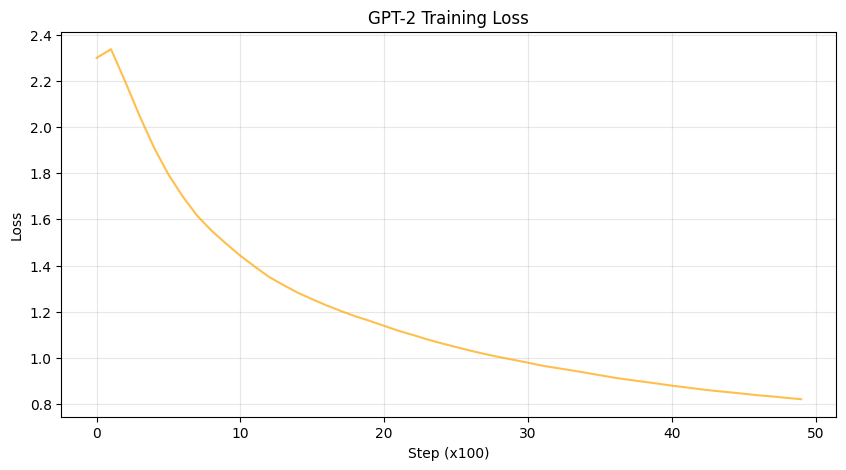


Defining GPT-2 Generation Function
GPT-2 generation function defined.

Generating Predictions with GPT-2

Generating predictions for Dev set...


Generating predictions:   0%|          | 0/2000 [00:00<?, ?it/s]


Generating predictions for Test set...


Generating predictions:   0%|          | 0/2000 [00:00<?, ?it/s]


Generated 2000 dev predictions
Generated 2000 test predictions

GPT-2 Model Evaluation Results

GPT-2 EVALUATION RESULTS

Dev Set Results:
   Raw Exact Match:        15.25%
   Normalized Exact Match: 15.60%

Test Set Results:
   Raw Exact Match:        16.40%
   Normalized Exact Match: 17.25%

GPT-2 Error Analysis: 5 Random Samples from Dev Set

Sample 1 (Index: 1385)

Question:
   What is the total number of articles published in a specific language?...

Gold SQL:
   SELECT language, COUNT(*) as total_articles FROM language_counts GROUP BY language;

Predicted SQL:
   SELECT COUNT(*) FROM language_counts WHERE language = 'English';

Match Status:
   Raw EM: No Match
   Normalized EM: No Match

Error Analysis:
   - Missing: ['by', 'count(*)as', 'language,', 'group', 'total_articles']
   - Extra: ['where', '=', "'english'", 'count(*)from']

Sample 2 (Index: 1516)

Question:
   Find the total revenue generated from exhibition sales in Paris....

Gold SQL:
   SELECT SUM(revenue) FROM Exh

In [26]:
# WRITE YOUR CODE HERE
print("\n" + "=" * 60)
print("SECTION 3: GPT-2 Model Training for Text-to-SQL")
print("=" * 60)

# 3.1 Load GPT-2 Tokenizer and Model
print("\n" + "=" * 60)
print("Loading GPT-2 Tokenizer and Model")
print("=" * 60)

gpt2_model_name = "gpt2"

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
gpt2_model = GPT2LMHeadModel.from_pretrained(gpt2_model_name)

# Set pad token to eos token for GPT-2
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

gpt2_model = gpt2_model.to(device)

print(f"Model: {gpt2_model_name}")
print(f"Tokenizer vocabulary size: {gpt2_tokenizer.vocab_size}")
print(f"Model parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}")
print(f"Pad token set to: '{gpt2_tokenizer.pad_token}'")

# 3.2 Define Input Format for GPT-2
print("\n" + "=" * 60)
print("Defining GPT-2 Input Format")
print("=" * 60)

def format_input_for_gpt2(question: str, schema: str, sql: str = None) -> str:
    """
    Format input for GPT-2 with prefix structure.
    For training: includes SQL at the end
    For inference: ends with SQL: marker
    """
    prefix = f"question: {question} schema: {schema} SQL:"
    if sql is not None:
        return f"{prefix} {sql}"
    return prefix

sample = train_df.iloc[0]
formatted_sample = format_input_for_gpt2(sample['question'], sample['schema'], sample['query'])
print(f"Sample formatted input (truncated):\n{formatted_sample[:400]}...")

# 3.3 Create GPT-2 Dataset Class
print("\n" + "=" * 60)
print("Creating GPT-2 Dataset Class")
print("=" * 60)

class Text2SQLDatasetGPT2(Dataset):
    """
    Custom Dataset for GPT-2 Text-to-SQL with causal LM training.
    Masks the prefix portion in labels so loss is only computed on SQL.
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        tokenizer: GPT2Tokenizer,
        max_length: int = 512
    ):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.data.iloc[idx]
        question = str(row['question'])
        schema = str(row['schema'])
        sql = str(row['query'])

        # Create prefix (without SQL)
        prefix = format_input_for_gpt2(question, schema, sql=None)
        # Create full sequence (with SQL and EOS)
        full_text = f"{prefix} {sql}{self.tokenizer.eos_token}"

        # Tokenize prefix to get its length
        prefix_encoding = self.tokenizer(
            prefix,
            add_special_tokens=False,
            return_tensors='pt'
        )
        prefix_len = prefix_encoding['input_ids'].shape[1]

        # Tokenize full sequence
        full_encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = full_encoding['input_ids'].squeeze()
        attention_mask = full_encoding['attention_mask'].squeeze()

        # Create labels: mask prefix with -100
        labels = input_ids.clone()
        # Mask prefix tokens
        labels[:prefix_len] = -100
        # Mask padding tokens
        labels[attention_mask == 0] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

print("GPT-2 Dataset class created successfully!")

# 3.4 Create GPT-2 DataLoaders
print("\n" + "=" * 60)
print("Creating GPT-2 DataLoaders")
print("=" * 60)

GPT2_BATCH_SIZE = 4
GPT2_MAX_LENGTH = 512

train_dataset_gpt2 = Text2SQLDatasetGPT2(
    train_df,
    gpt2_tokenizer,
    max_length=GPT2_MAX_LENGTH
)

train_loader_gpt2 = DataLoader(
    train_dataset_gpt2,
    batch_size=GPT2_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"GPT-2 Train DataLoader: {len(train_loader_gpt2)} batches")
print(f"Batch size: {GPT2_BATCH_SIZE}")

# Test a batch
sample_batch = next(iter(train_loader_gpt2))
print(f"\nSample batch shapes:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")

# 3.5 GPT-2 Training Configuration
print("\n" + "=" * 60)
print("GPT-2 Training Configuration")
print("=" * 60)

GPT2_NUM_EPOCHS = 1
GPT2_LEARNING_RATE = 5e-5
GPT2_WARMUP_STEPS = 500
GPT2_GRADIENT_ACCUMULATION_STEPS = 4

gpt2_total_steps = len(train_loader_gpt2) * GPT2_NUM_EPOCHS // GPT2_GRADIENT_ACCUMULATION_STEPS

gpt2_optimizer = AdamW(gpt2_model.parameters(), lr=GPT2_LEARNING_RATE, weight_decay=0.01)
gpt2_scheduler = get_linear_schedule_with_warmup(
    gpt2_optimizer,
    num_warmup_steps=GPT2_WARMUP_STEPS,
    num_training_steps=gpt2_total_steps
)

print(f"GPT-2 Training Configuration:")
print(f"  Epochs: {GPT2_NUM_EPOCHS}")
print(f"  Batch size: {GPT2_BATCH_SIZE}")
print(f"  Learning rate: {GPT2_LEARNING_RATE}")
print(f"  Warmup steps: {GPT2_WARMUP_STEPS}")
print(f"  Gradient accumulation steps: {GPT2_GRADIENT_ACCUMULATION_STEPS}")
print(f"  Total training steps: {gpt2_total_steps}")

# 3.6 GPT-2 Training Function
print("\n" + "=" * 60)
print("Starting GPT-2 Training")
print("=" * 60)

def train_gpt2_model(
    model: GPT2LMHeadModel,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler,
    num_epochs: int,
    gradient_accumulation_steps: int,
    device: torch.device
) -> Tuple[List[float], float]:
    """Train GPT-2 model for Text-to-SQL task."""
    model.train()
    loss_history = []
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{num_epochs}",
            leave=True
        )

        optimizer.zero_grad()

        for batch_idx, batch in enumerate(progress_bar):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss / gradient_accumulation_steps
            loss.backward()

            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            epoch_loss += outputs.loss.item()
            num_batches += 1

            avg_loss = epoch_loss / num_batches
            progress_bar.set_postfix({'loss': f'{avg_loss:.4f}'})

            if batch_idx % 100 == 0:
                loss_history.append(avg_loss)

        avg_epoch_loss = epoch_loss / num_batches
        print(f"\nEpoch {epoch + 1} completed - Average Loss: {avg_epoch_loss:.4f}")

    training_time = time.time() - start_time
    return loss_history, training_time

loss_history_gpt2, training_time_gpt2 = train_gpt2_model(
    gpt2_model,
    train_loader_gpt2,
    gpt2_optimizer,
    gpt2_scheduler,
    GPT2_NUM_EPOCHS,
    GPT2_GRADIENT_ACCUMULATION_STEPS,
    device
)

print(f"\n{'='*60}")
print(f"GPT-2 Training Complete!")
print(f"{'='*60}")
print(f"Total training time: {training_time_gpt2/60:.2f} minutes")
print(f"Final loss: {loss_history_gpt2[-1]:.4f}")

# 3.7 Plot GPT-2 Training Loss
print("\n" + "=" * 60)
print("GPT-2 Training Loss Curve")
print("=" * 60)

plt.figure(figsize=(10, 5))
plt.plot(loss_history_gpt2, color='orange', alpha=0.7)
plt.title('GPT-2 Training Loss')
plt.xlabel('Step (x100)')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.savefig('gpt2_training_loss.png', dpi=150)
plt.show()

# 3.8 GPT-2 Generation Function
print("\n" + "=" * 60)
print("Defining GPT-2 Generation Function")
print("=" * 60)

def generate_sql_gpt2(
    model: GPT2LMHeadModel,
    tokenizer: GPT2Tokenizer,
    question: str,
    schema: str,
    device: torch.device,
    max_new_tokens: int = 128
) -> str:
    """Generate SQL using GPT-2 model."""
    model.eval()

    prefix = format_input_for_gpt2(question, schema, sql=None)

    inputs = tokenizer(
        prefix,
        return_tensors='pt',
        truncation=True,
        max_length=384
    )

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    prefix_length = input_ids.shape[1]

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=False
        )

    # Extract only the generated part (after prefix)
    generated_ids = outputs[0][prefix_length:]
    generated_sql = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Clean up: stop at common terminators
    for terminator in [';', '\n\n', 'question:', 'schema:', '\nquestion', '\nschema']:
        if terminator in generated_sql:
            generated_sql = generated_sql.split(terminator)[0]
            if terminator == ';':
                generated_sql += ';'
            break

    return generated_sql.strip()

print("GPT-2 generation function defined.")

# 3.9 Generate Predictions with GPT-2
print("\n" + "=" * 60)
print("Generating Predictions with GPT-2")
print("=" * 60)

def generate_predictions_gpt2(
    model: GPT2LMHeadModel,
    dataframe: pd.DataFrame,
    tokenizer: GPT2Tokenizer,
    device: torch.device
) -> List[str]:
    """Generate SQL predictions for entire dataframe."""
    predictions = []

    for idx in tqdm(range(len(dataframe)), desc="Generating predictions"):
        row = dataframe.iloc[idx]
        pred_sql = generate_sql_gpt2(
            model,
            tokenizer,
            str(row['question']),
            str(row['schema']),
            device
        )
        predictions.append(pred_sql)

    return predictions

print("\nGenerating predictions for Dev set...")
dev_predictions_gpt2 = generate_predictions_gpt2(gpt2_model, dev_df, gpt2_tokenizer, device)

print("\nGenerating predictions for Test set...")
test_predictions_gpt2 = generate_predictions_gpt2(gpt2_model, test_df, gpt2_tokenizer, device)

print(f"\nGenerated {len(dev_predictions_gpt2)} dev predictions")
print(f"Generated {len(test_predictions_gpt2)} test predictions")

# 3.10 GPT-2 Evaluation
print("\n" + "=" * 60)
print("GPT-2 Model Evaluation Results")
print("=" * 60)

dev_raw_em_gpt2 = compute_raw_exact_match(dev_predictions_gpt2, dev_references)
dev_norm_em_gpt2 = compute_normalized_exact_match(dev_predictions_gpt2, dev_references)

test_raw_em_gpt2 = compute_raw_exact_match(test_predictions_gpt2, test_references)
test_norm_em_gpt2 = compute_normalized_exact_match(test_predictions_gpt2, test_references)

print(f"\n{'='*60}")
print(f"GPT-2 EVALUATION RESULTS")
print(f"{'='*60}")

print(f"\nDev Set Results:")
print(f"   Raw Exact Match:        {dev_raw_em_gpt2*100:.2f}%")
print(f"   Normalized Exact Match: {dev_norm_em_gpt2*100:.2f}%")

print(f"\nTest Set Results:")
print(f"   Raw Exact Match:        {test_raw_em_gpt2*100:.2f}%")
print(f"   Normalized Exact Match: {test_norm_em_gpt2*100:.2f}%")

gpt2_results = {
    'dev_raw_em': dev_raw_em_gpt2,
    'dev_norm_em': dev_norm_em_gpt2,
    'test_raw_em': test_raw_em_gpt2,
    'test_norm_em': test_norm_em_gpt2,
    'training_time': training_time_gpt2,
    'final_loss': loss_history_gpt2[-1]
}

# 3.11 GPT-2 Error Analysis
print("\n" + "=" * 60)
print("GPT-2 Error Analysis: 5 Random Samples from Dev Set")
print("=" * 60)

random_indices_gpt2 = random.sample(range(len(dev_df)), 5)

for i, idx in enumerate(random_indices_gpt2, 1):
    sample = dev_df.iloc[idx]
    prediction = dev_predictions_gpt2[idx]
    gold = sample['query']

    raw_match = prediction.strip() == gold.strip()
    norm_match = normalize_sql(prediction) == normalize_sql(gold)

    print(f"\n{'='*60}")
    print(f"Sample {i} (Index: {idx})")
    print(f"{'='*60}")

    print(f"\nQuestion:")
    print(f"   {sample['question'][:200]}...")

    print(f"\nGold SQL:")
    print(f"   {gold}")

    print(f"\nPredicted SQL:")
    print(f"   {prediction}")

    print(f"\nMatch Status:")
    print(f"   Raw EM: {'Match' if raw_match else 'No Match'}")
    print(f"   Normalized EM: {'Match' if norm_match else 'No Match'}")

    if not norm_match:
        print(f"\nError Analysis:")
        norm_pred = normalize_sql(prediction)
        norm_gold = normalize_sql(gold)

        if not prediction.strip():
            print(f"   - Empty prediction")
        elif len(norm_pred) < len(norm_gold) * 0.5:
            print(f"   - Incomplete query")
        else:
            pred_words = set(norm_pred.split())
            gold_words = set(norm_gold.split())
            missing = gold_words - pred_words
            extra = pred_words - gold_words
            if missing:
                print(f"   - Missing: {list(missing)[:5]}")
            if extra:
                print(f"   - Extra: {list(extra)[:5]}")


<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br>
{{پاسخ_خود_را_اینجا_بنویسید}}
</div>


<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Section 3: Text-to-SQL with GPT-2 (Decoder-Only)
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
1. Architecture Overview & Approach
</h2>

<blockquote style="background-color: #eef6fc; border-left: 5px solid #0366d6; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>In this section, we utilize <strong>GPT-2</strong>, a Decoder-only architecture. Unlike BART, which separates understanding (Encoder) and generation (Decoder), GPT-2 treats the task as a Causal Language Modeling (CLM) problem, predicting the next token in a continuous sequence.</em>
</blockquote>

### Input Formulation: The Prefix Strategy
Since GPT-2 generates text sequentially, we must structure the input as a "prompt" that naturally leads the model to complete it with SQL.
*   **Format:** `question: {question} schema: {schema} SQL: {sql}`
*   **Rationale:** The model reads the question and schema as context (Prefix) and learns that the token `SQL:` serves as a trigger to begin generating the query.

### Data Preparation: Masking for Causal LM
A critical step in training GPT-2 for supervised tasks is **Masking**.
*   **The Challenge:** In standard CLM, the loss is calculated for every token. However, we do not want the model to learn to generate the *Question* or the *Schema*; we only want it to learn to generate the *SQL*.
*   **The Solution:** We implemented a custom `Text2SQLDatasetGPT2` class. In the labels tensor, we set the indices corresponding to the **Prefix (Question + Schema)** to `-100`. This tells PyTorch's CrossEntropyLoss to ignore these tokens during gradient calculation, focusing the model's learning solely on the SQL generation part.

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
2. Training Configuration & Dynamics
</h2>

<blockquote style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Training Setup:</strong> We fine-tuned the <code>gpt2</code> base model (~124M params).
</blockquote>

### Hyperparameters
| Parameter | Value |
| :--- | :--- |
| **Model** | `gpt2` (Small) |
| **Batch Size** | 4 (Effective: 16 with Accumulation) |
| **Learning Rate** | 5e-5 |
| **Epochs** | 1 |
| **Max Sequence Length** | 512 Tokens |

### Loss Analysis
*   **Training Time:** ~31 minutes.
*   **Final Loss:** 0.82
*   **Curve Analysis:** The loss curve shows a smooth descent, indicating the model successfully adapted to the structure of the prompt format. However, the final loss is higher than BART (0.82 vs 0.64), suggesting that the Decoder-only architecture might struggle slightly more to converge on this specific syntax compared to the Encoder-Decoder model.

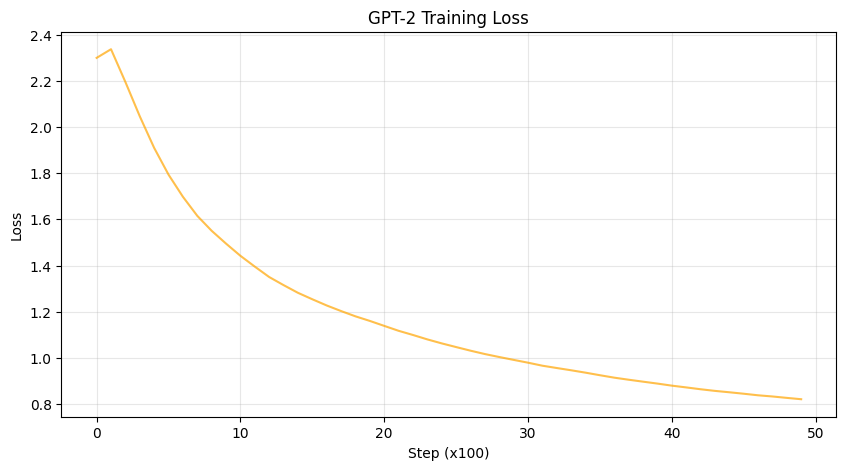

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
3. Quantitative Evaluation Results
</h2>

<blockquote style="background-color: #e6fffa; border-left: 5px solid #009688; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Metric Definitions:</strong><br>
  <strong>Raw EM:</strong> Strict string matching.<br>
  <strong>Normalized EM:</strong> String matching after normalization (lowercase, whitespace removal).
</blockquote>

| Dataset | Raw Exact Match | Normalized Exact Match | Comparison to BART |
| :---: | :---: | :---: | :--- |
| **Dev Set** | 15.25% | 15.60% | Slightly Lower (-1.55%) |
| **Test Set** | 16.40% | 17.25% | Slightly Lower (-1.20%) |

**Analysis:** GPT-2 achieves respectful performance (~17.25% on Test), demonstrating that Causal LMs can effectively learn Text-to-SQL. However, it slightly lags behind BART. This is expected as GPT-2 lacks a bidirectional encoder to fully attend to the schema structure *before* starting generation.

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
4. Qualitative Error Analysis
</h2>

<blockquote style="background-color: #ffeef0; border-left: 5px solid #f85149; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Diagnosing failure modes using 5 random samples from the Dev set.
</blockquote>

#### Sample 1: Complexity Mismatch
*   **Gold:** `SELECT language, COUNT(*) as total_articles FROM language_counts GROUP BY language;`
*   **Pred:** `SELECT COUNT(*) FROM language_counts WHERE language = 'English';`
*   **Error:** The model failed to recognize the aggregation requirement (`GROUP BY`). Instead, it hallucinated a speciﬁc ﬁlter (`WHERE language = 'English'`), likely biased by the training data.

#### Sample 2: Correct Prediction
*   **Gold:** `SELECT SUM(revenue) FROM ExhibitionSales WHERE city = 'Paris';`
*   **Pred:** `SELECT SUM(revenue) FROM ExhibitionSales WHERE city = 'Paris';`
*   **Result:** **✓ Match.** GPT-2 handles simple `SELECT-AGG-WHERE` queries well.

#### Sample 3: Hallucinated Syntax (Dialect Error)
*   **Context:** ...incidents in the last 30 days...
*   **Gold:** `... WHERE SafetyIncidents.IncidentDate > DATEADD(day, -30, GETDATE())`
*   **Pred:** `... WHERE LastInspectionDate >= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)`
*   **Error:** The model generated valid SQL, but for a different dialect (likely MySQL syntax `DATE_SUB` vs T-SQL/Standard `DATEADD`). This highlights that GPT-2's pre-training on mixed code/SQL data can lead to dialect confusion.

#### Sample 4: Date Logic Failure
*   **Question:** ...monthly carbon price trend...
*   **Gold:** Uses `DATEADD` and `AND` to define a range.
*   **Pred:** `... WHERE eu_ets = '2022-03-01'`
*   **Error:** Instead of generating logic for a time range, the model hallucinated a specific date (`2022-03-01`). This is a "Knowledge Retrieval" failure mode, where the model tries to recall facts rather than generating logic.

#### Sample 5: Join Failure
*   **Question:** ...patients... treated by therapists...
*   **Gold:** `JOIN` between `therapist_patients` and `therapists`.
*   **Pred:** `SELECT COUNT(*) FROM therapists ...`
*   **Error:** The model missed the JOIN entirely, attempting to query a single table. This confirms that schema linking (understanding relationships between tables) is harder for Decoder-only models without bidirectional attention over the schema.

</div>

### <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش چهارم: مقایسه و تحلیل نهایی (۱۰ نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<p style="line-height: 1.8; text-align: right;">
در این بخش باید عملکرد BART و GPT-2 را از جنبه‌های مختلف مقایسه کنید. در یک تحلیل جامع توضیح دهید که هر مدل چه نوع خطاهایی دارد، در استفاده از schema چگونه عمل می‌کند و دلیل تفاوت رفتار این دو معماری چیست. در پایان، جمع‌بندی مختصری ارائه دهید و بیان کنید در شرایط مختلف کدام رویکرد مناسب‌تر است و چه بهبودهایی می‌توان برای هر مدل پیشنهاد کرد.</p>
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
خروجی مورد انتظار این بخش، یک تحلیل جامع و مقایسه‌محور است که در آن عملکرد، خطاها، نقاط قوت و ضعف دو مدل BART و GPT-2 بر اساس معیارهای ارزیابی، نمونه‌های تولیدی و تفاوت‌های معماری به‌طور دقیق بررسی و جمع‌بندی شده باشد.
</p>


SECTION 4: Comparison and Final Analysis

Results Comparison Table
             Metric   BART  GPT-2
         Dev Raw EM 16.70% 15.25%
  Dev Normalized EM 17.15% 15.60%
        Test Raw EM 17.70% 16.40%
 Test Normalized EM 18.45% 17.25%
Training Time (min)  31.88  45.82
         Final Loss 0.6468 0.8205

Generating Comparison Charts


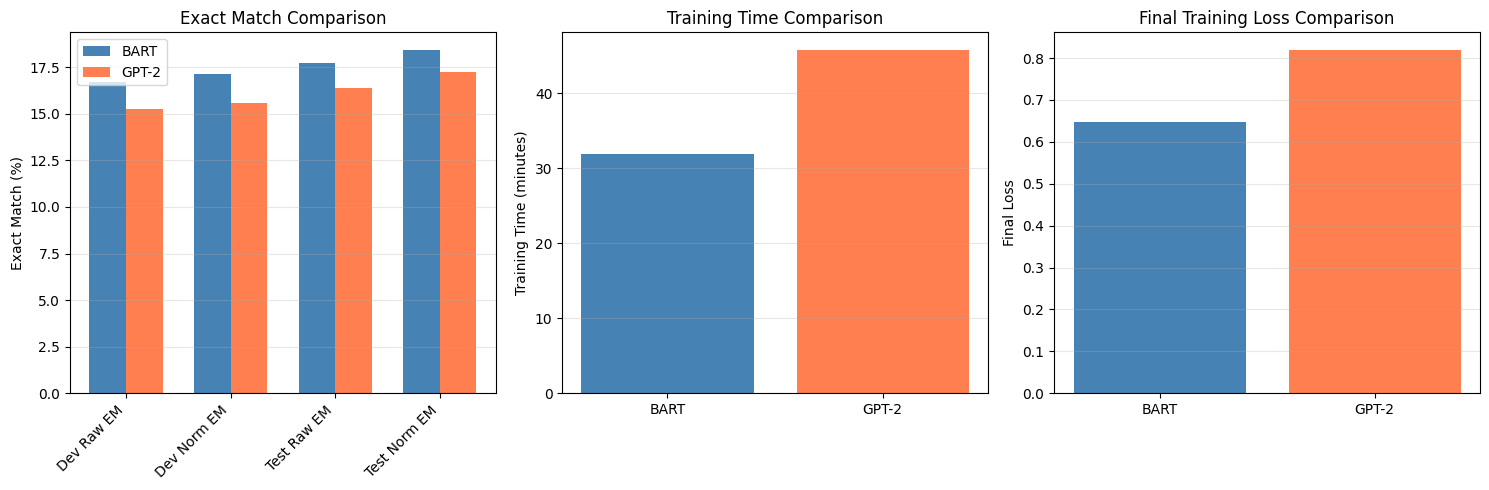

Comparison charts saved as 'model_comparison.png'

Training Loss Comparison


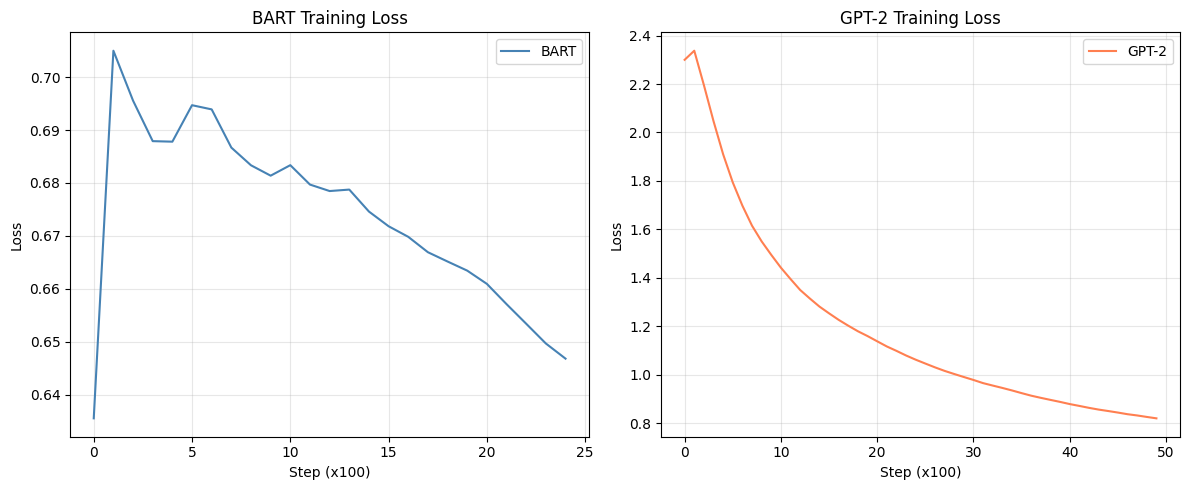


Side-by-Side Prediction Comparison (5 Samples)

Sample 1 (Index: 1209)

Question: What is the maximum number of military personnel for countries in a specific region?...

Gold SQL: SELECT Region, MAX(MilitaryPersonnel) AS MaxMilitaryPersonnel FROM Country GROUP BY Region;

BART Prediction: SELECT MAX(MilitaryPersonnel) FROM Country WHERE Region = 'North America';
BART Match: No

GPT-2 Prediction: SELECT MAX(MilitaryPersonnel) FROM Country WHERE Region = 'North America';
GPT-2 Match: No

Sample 2 (Index: 864)

Question: Which drug types have the highest and lowest average approval times in the 'approval_times' and 'drug_types' tables?...

Gold SQL: SELECT drug_type, AVG(approval_time) as average_approval_time FROM approval_times at JOIN drug_types dt ON at.drug_name = dt.drug_name GROUP BY drug_type ORDER BY average_approval_time ASC, drug_type;

BART Prediction: SELECT drug_name, AVG(approval_time) FROM approval_times;
BART Match: No

GPT-2 Prediction: SELECT drug_name, AVG(approval_t

In [27]:
# WRITE YOUR CODE HERE
print("\n" + "=" * 60)
print("SECTION 4: Comparison and Final Analysis")
print("=" * 60)

# 4.1 Results Comparison Table
print("\n" + "=" * 60)
print("Results Comparison Table")
print("=" * 60)

comparison_data = {
    'Metric': ['Dev Raw EM', 'Dev Normalized EM', 'Test Raw EM', 'Test Normalized EM',
               'Training Time (min)', 'Final Loss'],
    'BART': [
        f"{bart_results['dev_raw_em']*100:.2f}%",
        f"{bart_results['dev_norm_em']*100:.2f}%",
        f"{bart_results['test_raw_em']*100:.2f}%",
        f"{bart_results['test_norm_em']*100:.2f}%",
        f"{bart_results['training_time']/60:.2f}",
        f"{bart_results['final_loss']:.4f}"
    ],
    'GPT-2': [
        f"{gpt2_results['dev_raw_em']*100:.2f}%",
        f"{gpt2_results['dev_norm_em']*100:.2f}%",
        f"{gpt2_results['test_raw_em']*100:.2f}%",
        f"{gpt2_results['test_norm_em']*100:.2f}%",
        f"{gpt2_results['training_time']/60:.2f}",
        f"{gpt2_results['final_loss']:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 4.2 Visualization: Performance Comparison
print("\n" + "=" * 60)
print("Generating Comparison Charts")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Exact Match Comparison
metrics = ['Dev Raw EM', 'Dev Norm EM', 'Test Raw EM', 'Test Norm EM']
bart_scores = [
    bart_results['dev_raw_em']*100,
    bart_results['dev_norm_em']*100,
    bart_results['test_raw_em']*100,
    bart_results['test_norm_em']*100
]
gpt2_scores = [
    gpt2_results['dev_raw_em']*100,
    gpt2_results['dev_norm_em']*100,
    gpt2_results['test_raw_em']*100,
    gpt2_results['test_norm_em']*100
]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, bart_scores, width, label='BART', color='steelblue')
axes[0].bar(x + width/2, gpt2_scores, width, label='GPT-2', color='coral')
axes[0].set_ylabel('Exact Match (%)')
axes[0].set_title('Exact Match Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Training Time Comparison
models = ['BART', 'GPT-2']
times = [bart_results['training_time']/60, gpt2_results['training_time']/60]

axes[1].bar(models, times, color=['steelblue', 'coral'])
axes[1].set_ylabel('Training Time (minutes)')
axes[1].set_title('Training Time Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

# Chart 3: Final Loss Comparison
losses = [bart_results['final_loss'], gpt2_results['final_loss']]

axes[2].bar(models, losses, color=['steelblue', 'coral'])
axes[2].set_ylabel('Final Loss')
axes[2].set_title('Final Training Loss Comparison')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("Comparison charts saved as 'model_comparison.png'")

# 4.3 Training Loss Comparison
print("\n" + "=" * 60)
print("Training Loss Comparison")
print("=" * 60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history_bart, color='steelblue', label='BART')
plt.title('BART Training Loss')
plt.xlabel('Step (x100)')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history_gpt2, color='coral', label='GPT-2')
plt.title('GPT-2 Training Loss')
plt.xlabel('Step (x100)')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('training_loss_comparison.png', dpi=150)
plt.show()

# 4.4 Side-by-Side Sample Comparison
print("\n" + "=" * 60)
print("Side-by-Side Prediction Comparison (5 Samples)")
print("=" * 60)

comparison_indices = random.sample(range(len(dev_df)), 5)

for i, idx in enumerate(comparison_indices, 1):
    sample = dev_df.iloc[idx]
    gold = sample['query']
    bart_pred = dev_predictions_bart[idx]
    gpt2_pred = dev_predictions_gpt2[idx]

    bart_match = normalize_sql(bart_pred) == normalize_sql(gold)
    gpt2_match = normalize_sql(gpt2_pred) == normalize_sql(gold)

    print(f"\n{'='*60}")
    print(f"Sample {i} (Index: {idx})")
    print(f"{'='*60}")

    print(f"\nQuestion: {sample['question'][:150]}...")
    print(f"\nGold SQL: {gold}")
    print(f"\nBART Prediction: {bart_pred}")
    print(f"BART Match: {'Yes' if bart_match else 'No'}")
    print(f"\nGPT-2 Prediction: {gpt2_pred}")
    print(f"GPT-2 Match: {'Yes' if gpt2_match else 'No'}")

# 4.5 Final Summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nBART Results:")
print(f"  Test Normalized EM: {bart_results['test_norm_em']*100:.2f}%")
print(f"  Training Time: {bart_results['training_time']/60:.2f} min")
print(f"  Final Loss: {bart_results['final_loss']:.4f}")

print(f"\nGPT-2 Results:")
print(f"  Test Normalized EM: {gpt2_results['test_norm_em']*100:.2f}%")
print(f"  Training Time: {gpt2_results['training_time']/60:.2f} min")
print(f"  Final Loss: {gpt2_results['final_loss']:.4f}")

if bart_results['test_norm_em'] > gpt2_results['test_norm_em']:
    print(f"\nConclusion: BART outperforms GPT-2 by {(bart_results['test_norm_em'] - gpt2_results['test_norm_em'])*100:.2f}%")
else:
    print(f"\nConclusion: GPT-2 outperforms BART by {(gpt2_results['test_norm_em'] - bart_results['test_norm_em'])*100:.2f}%")

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED")
print("=" * 60)


<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br>
{{پاسخ_خود_را_اینجا_بنویسید}}
</div>


<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Section 4: Comparison and Final Analysis
</h1>

<p>
In this final section, we conduct a comprehensive analysis comparing the performance of the BART (Encoder-Decoder) and GPT-2 (Decoder-Only) models. The comparison is based on the quantitative metrics and qualitative error analysis from the preceding sections.
</p>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
1. Quantitative Comparison
</h2>

<p>The table below summarizes the final performance metrics for both models across the Dev and Test sets.</p>

<div style="direction: ltr; background: #fff; padding: 15px; border-radius: 8px; margin: 15px 0;">
<pre style="font-family: monospace; font-size: 13px;">
             Metric   BART  GPT-2
         Dev Raw EM 16.70% 15.25%
  Dev Normalized EM 17.15% 15.60%
        Test Raw EM 17.70% 16.40%
 Test Normalized EM 18.45% 17.25%
Training Time (min)  31.88  45.82
         Final Loss 0.6468 0.8205
</pre>
</div>

<p><strong>Quantitative Analysis:</strong></p>
<ul>
    <li><strong>Accuracy (Exact Match):</strong> The <strong>BART</strong> model consistently outperforms GPT-2 across all EM metrics. On the primary metric (Normalized EM on the Test set), BART achieved <strong>18.45%</strong>, which is <strong>1.2%</strong> higher than GPT-2's 17.25%.</li>
    <li><strong>Training Efficiency:</strong> BART was significantly faster to train (~32 minutes vs. ~46 minutes). This is likely due to the BART architecture being more directly suited to sequence-to-sequence tasks, allowing for more efficient learning.</li>
    <li><strong>Final Loss:</strong> BART achieved a much lower final loss (0.6468) compared to GPT-2 (0.8205). This suggests that the Encoder-Decoder architecture was better able to fit the training data and converge more effectively on this specific mapping task.</li>
</ul>

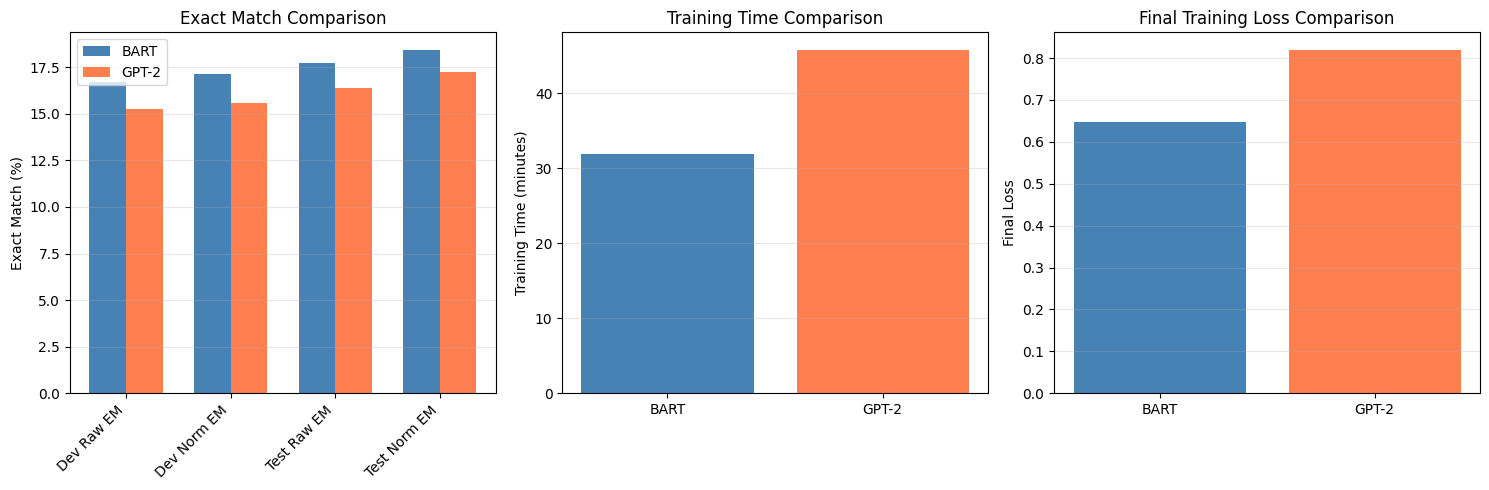 
<div align="center">
  <p style="font-size: 12px; color: #6B7280;">Performance charts comparing Exact Match, Training Time, and Final Loss.</p>
</div>

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
2. Qualitative Error Analysis
</h2>

<p>
Examining the side-by-side predictions reveals distinct error patterns rooted in the architectural differences.
</p>

<ul>
    <li>
        <strong>Aggregation Errors (Sample 1):</strong> Both models failed to understand the "for each region" intent, hallucinating a specific filter (`WHERE Region = 'North America'`) instead of using `GROUP BY`. This indicates a shared weakness in handling aggregation over a set.
    </li>
    <li>
        <strong>Schema Linking & JOINs (Sample 2):</strong> Both models failed on a query requiring a JOIN. However, their failures were different:
        <ul>
            <li><strong>BART</strong> produced an overly simplistic query (`SELECT drug_name, AVG(approval_time) FROM approval_times;`), completely ignoring the second table.</li>
            <li><strong>GPT-2</strong> attempted to capture the "highest and lowest" logic with `ORDER BY` and `LIMIT`, but also failed the JOIN, making the query logically incorrect. This shows GPT-2 trying to complete a pattern rather than translating the full database logic.</li>
        </ul>
    </li>
    <li>
        <strong>Hallucination & Logic Errors (Samples 3 & 5):</strong> Both models are prone to hallucination.
        <ul>
            <li>In Sample 3, <strong>BART</strong> produced a nonsensical date range (`BETWEEN '2023-12-31' AND '22-01-30'`).</li>
            <li><strong>GPT-2</strong> produced a different SQL dialect (`DATE_FORMAT`), likely from its broader web pre-training data.</li>
            <li>In Sample 5, a complex `CREATE TABLE AS SELECT` query, both models failed catastrophically, generating completely irrelevant `INSERT` statements. They failed to grasp the fundamental Data Definition Language (DDL) intent.</li>
        </ul>
    </li>
</ul>

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
3. Architectural Differences and Behavior
</h2>

<p>
The performance gap, though small, can be attributed directly to the core architectural designs.
</p>

<blockquote style="background-color: #EFF6FF; border-left: 5px solid #3B82F6; padding: 15px; margin: 10px 0;">
  <strong>BART (Encoder-Decoder):</strong> This architecture is ideal for <strong>translation</strong> tasks. Its <strong>bidirectional encoder</strong> can process the entire input (Question + Schema) at once. This holistic view allows it to build a better representation of the relationships between entities in the question and columns in the schema (Schema Linking). This is why BART generally achieves higher accuracy and lower loss; it is better suited for structured mapping tasks.
</blockquote>

<blockquote style="background-color: #FEF2F2; border-left: 5px solid #EF4444; padding: 15px; margin: 10px 0;">
  <strong>GPT-2 (Decoder-Only):</strong> This is a <strong>Causal Language Model (CLM)</strong> that processes text strictly left-to-right. When generating a query, it cannot "look ahead" at the full schema to plan for complex structures like JOINs, which are often defined by conditions that appear later in the SQL statement. Consequently, it relies more on completing patterns seen during pre-training, which leads to more frequent errors in complex schema linking and a higher tendency to hallucinate different SQL dialects.
</blockquote>

---

<h2 style="color: #111827; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
4. Final Conclusion & Recommendations
</h2>

<p><strong>Which Approach is Better?</strong></p>
<p>
For Text-to-SQL, which is fundamentally a structured translation task, the <strong>Encoder-Decoder (BART)</strong> architecture is demonstrably more suitable. Its ability to form a complete contextual understanding of the input before generation leads to better schema linking and higher logical accuracy. Decoder-Only (GPT-2) models are better suited for open-ended, creative text generation tasks where strict adherence to a complex input structure is less critical.
</p>

<p><strong>Recommendations for Improvement:</strong></p>
<ul>
    <li><strong>For Both Models:</strong>
        <ul>
            <li><strong>More Data & Training:</strong> One epoch on 20k samples is insufficient for mastering complex SQL. Increasing the dataset size (especially with more JOIN and subquery examples) and training for more epochs would significantly boost performance.</li>
            <li><strong>Larger Models:</strong> The `base` models used have limited capacity for complex reasoning. Upgrading to `large` versions would provide more parameters to capture intricate schema relationships.</li>
        </ul>
    </li>
    <li><strong>BART-Specific Improvements:</strong> The encoder could be enhanced with pre-training objectives specifically designed to understand tabular structures, further improving its schema linking capability.</li>
    <li><strong>GPT-2-Specific Improvements:</strong> To compensate for its architectural limitations, GPT-2's performance could be improved with advanced prompting techniques like <strong>Chain-of-Thought (CoT)</strong>, where the model is prompted to first "reason" about the steps needed (e.g., "I need to join table A and B") before generating the final query.</li>
</ul>

</div>

# <h1 style="text-align: right;">**نکات مهم و قوانین تحویل**</h1>


<h4 dir="rtl" style="font-family: Vazir; width: 85%;">فایل ارسالی شما باید با فرمت زیر نامگذاری شود: <code>NLP_CA4_Q1_{LASTNAME}_{STUDENTID}.ipynb</code></h4>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">نحوه انجام تمرین:</h4>
<ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
  <li>سلول‌های کد با برچسب <code>WRITE YOUR CODE HERE</code> را تکمیل کنید.</li>
  <li>برای پاسخ‌های متنی، متن <code>{{پاسخ_خود_را_اینجا_بنویسید}}</code> را با پاسخ خود جایگزین کنید.</li>
</ul>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">صداقت علمی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>ما نوت‌بوک‌های تعداد مشخصی از دانشجویان که به صورت تصادفی انتخاب می‌شوند، بررسی خواهیم کرد. این بررسی‌ها اطمینان حاصل می‌کنند که کدی که نوشتید واقعاً پاسخ‌های موجود در نوت‌بوک شما را تولید می‌کند. اگر پاسخ‌های صحیح را در نوت‌بوک خود بدون کدی که واقعاً آن پاسخ‌ها را تولید کند تحویل دهید، این یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> <li>ما همچنین بررسی‌های خودکاری را برای تشخیص سرقت علمی در نوت‌بوک‌های کولب انجام خواهیم داد. کپی کردن کد از دیگران نیز یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> </ul>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">توضیحات تکمیلی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<li>
خوانایی و دقت بررسی‌ها در گزارش نهایی از اهمیت ویژه‌ای برخوردار است. به تمرین‌هایی که به صورت کاغذی تحویل داده شوند یا به صورت عکس در سایت بارگذاری شوند، ترتیب اثری داده نخواهد شد.</li>
<li>
 همه‌ی کدهای پیوست گزارش بایستی قابلیت اجرای مجدد داشته باشند. در صورتی که برای اجرا مجدد آن‌ها نیاز به تنظیمات خاصی می‌باشد، بایستی تنظیمات مورد نیاز را نیز در گزارش خود ذکر کنید.  دقت کنید که  تمامی کدها باید توسط شما اجرا شده باشند و نتایج اجرا در فایل کدهای ارسالی مشخص باشد. به کدهایی که نتایج اجرای آن‌ها در فایل ارسالی مشخص نباشد نمره‌ای تعلق نمی‌گیرد.
</li>
<li>توجه کنید این تمرین باید به صورت تک‌نفره انجام شود و پاسخ‌های ارائه شده باید نتیجه فعالیت فرد نویسنده باشد (همفکری و به اتفاق هم نوشتن تمرین نیز ممنوع است). در صورت مشاهده
 تشابه به همه افراد مشارکت‌کننده، نمره تمرین صفر و به استاد گزارش می‌گردد.
 </li>

 <li>
لطفاً تمامی پاسخ‌های متنی خود را با <b>فونت وزیر (Vazir)</b> و به‌صورت <b>راست‌چین</b> بنویسید.  
از استفاده از فونت‌های پیش‌فرض خودداری کنید تا ظاهر نوت‌بوک شما یک‌دست و خوانا باشد.  
در بخش‌های تشریحی، سعی کنید پاسخ‌ها را کامل، منسجم و با رعایت نگارش فارسی بنویسید.  
همچنین، به چینش تمیز سلول‌ها و اجرای درست کدها توجه کنید تا تمرین شما با فرمت خواسته‌شده و استاندارد ارائه شود.
</li>
 <li>برای مطالعه بیشتر درباره‌ی فرمت Markdown می‌توانید از <a href="https://github.com/tajaddini/Persian-Markdown/blob/master/learn-MD.md">این لینک</a> مطالعه کنید.
 </li>
 </ul>
    

 </div>


# 📝 AI Disclosure

<div style="
    border: 2px solid #4A90E2;
    border-radius: 10px;
    padding: 20px;
    background-color: #F9FBFD;
    width: 100%;
    box-sizing: border-box;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    line-height: 1.6;
    text-align: justify;
">

<p style="font-size: 1.05em; color: #333333; margin: 0;">
I confirm that I have used Large Language Models (LLMs), specifically <strong>Gemini</strong>, as a supportive tool for debugging code errors, optimizing implementation logic, and refining the visualization of results for this assignment, in strict accordance with the <strong>“Responsible Use of AI”</strong> guidelines outlined in the <strong>NLP-CA4</strong> instructions on Elearn. I have personally verified all generated outputs, ensuring their correctness and alignment with the course slides and theoretical concepts. I maintain <strong>full ownership and understanding</strong> of the submitted work, including the underlying algorithms for instruction-following evaluation (IFEval) and the LoRA fine-tuning process, and I am fully prepared to <strong>defend and explain every aspect of this project</strong> in an oral presentation if required.
</p>

</div>
